# Trend calculations

### 1. Loading continious and survey files
### 2. Correcting continious data from solid earth tides and cleaning the 5 first 

In [1]:
import pandas as pd
import glob
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. CONFIGURATION DES CHEMINS
path = "Continuous_files_basement/"
all_files = glob.glob(os.path.join(path, "*.csv"))
all_files.sort()

# 2. CHARGEMENT ET CORRECTION DU BASEMENT
def load_and_correct_basement(files):
    blocks = {}
    for i, f in enumerate(files):
        df = pd.read_csv(f)
        
        # --- NETTOYAGE & CORRECTION ---
        df = df.iloc[5:].copy() # Supprime les 5 premières lignes
        
        # Correction Solid Earth Tides
        df['G_corr'] = df['ObsG'] - df['Earthtide']
            
        # --- TEMPS ET INDEX ---
        df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
        df['file_index'] = i
        df['filename'] = os.path.basename(f)
        
        blocks[i] = df
    return blocks

# Exécution du chargement
data_blocks = load_and_correct_basement(all_files)

# 3. CHARGEMENT DU SURVEY (TÉNÉRIFE)
G_survey = pd.read_csv("Final_Precise_Raw_Gravity_Data.csv", sep=';', decimal=',')
G_survey['datetime'] = pd.to_datetime(G_survey['Date'] + ' ' + G_survey['Time'])

print(f"✅ {len(data_blocks)} fichiers Basement chargés et corrigés (G_corr).")
print(f"✅ Survey Ténérife chargé ({len(G_survey)} points).")

✅ 22 fichiers Basement chargés et corrigés (G_corr).
✅ Survey Ténérife chargé (1077 points).


# SURVEY DETAILS

## SURVEY 1 - APRIL (2-3)

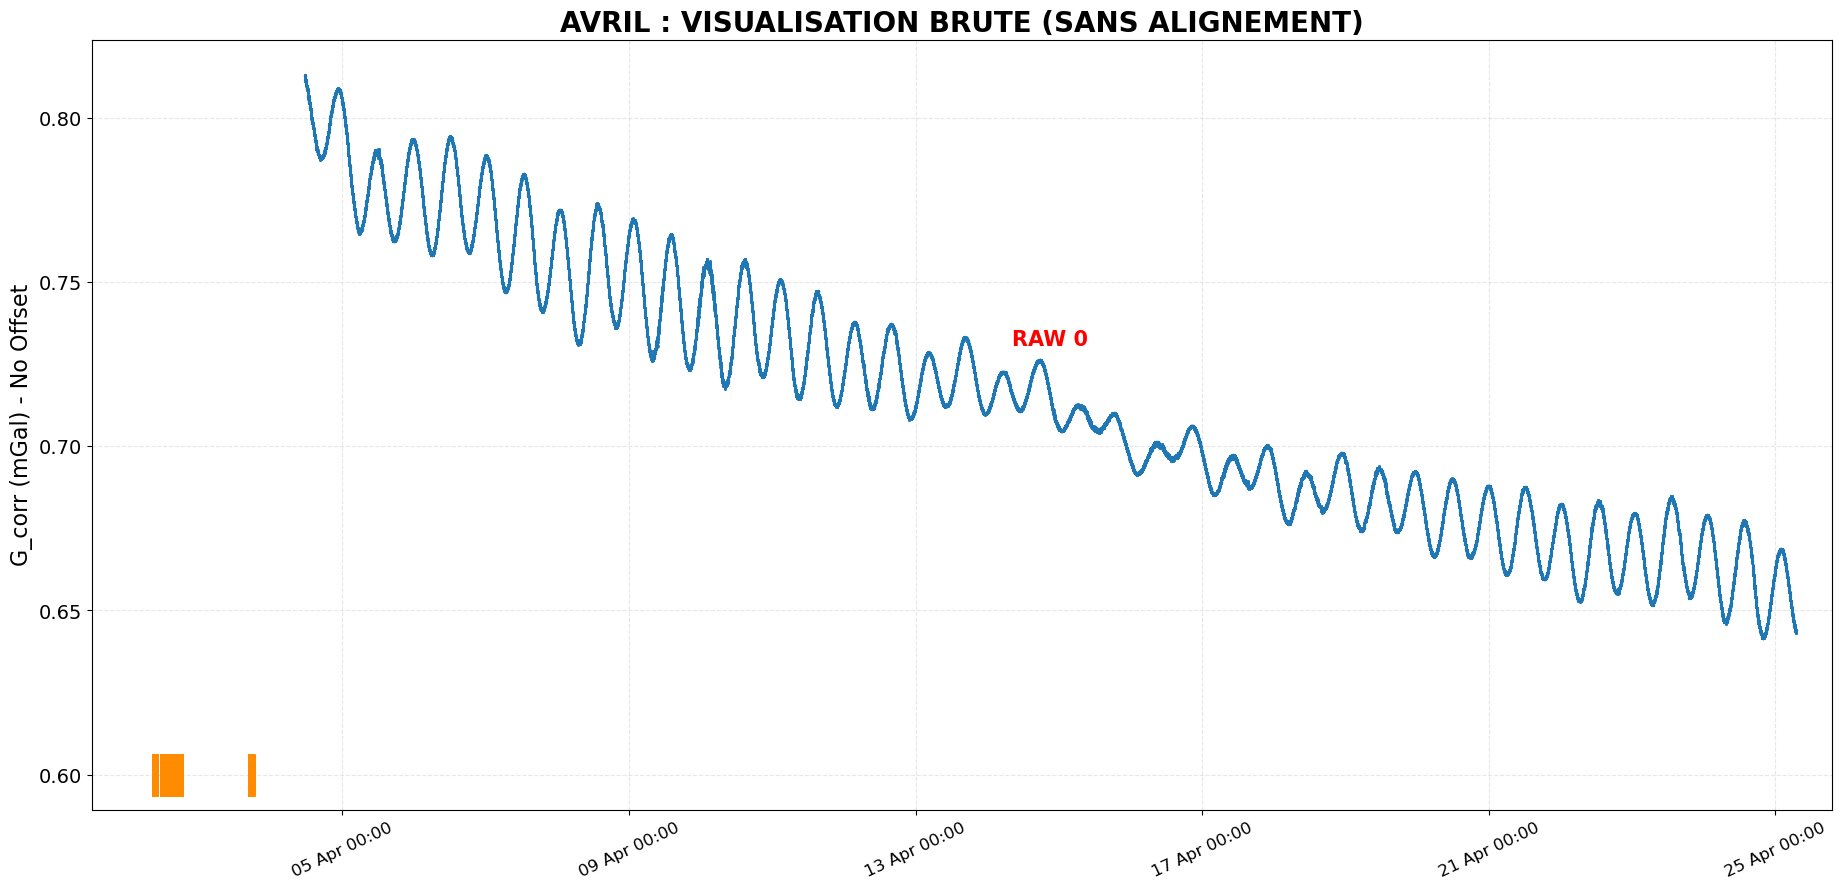

In [2]:
# ==========================================
# CELLULE : VISUALISATION RAW - AVRIL (File 0)
# ==========================================
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# On définit l'indice pour Avril (uniquement le premier fichier)
indices_avril = [0]
plt.figure(figsize=(20, 10))

# 1. TRACÉ DES DONNÉES SANS AUCUN OFFSET
for idx in indices_avril:
    # On récupère le bloc original (G_corr uniquement)
    df_raw = data_blocks[idx].copy()
    
    plt.plot(df_raw['datetime'], df_raw['G_corr'], 'o', markersize=1.2, label=f'File {idx} (Raw)')
    
    # Repère visuel pour l'ID (placé un peu au-dessus de la médiane du bloc)
    mid_time = df_raw['datetime'].iloc[len(df_raw)//2]
    plt.text(mid_time, df_raw['G_corr'].median() + 0.02, f"RAW {idx}", 
             color='red', fontsize=15, fontweight='bold', ha='center')

# 2. TIMELINE SURVEY (Orange)
# On filtre le survey pour le début du mois d'avril (2-3 Avril)
# On élargit un peu le masque pour être sûr de bien attraper les points
mask_s = (G_survey['datetime'] >= '2024-04-01') & (G_survey['datetime'] <= '2024-04-05')
survey_avril = G_survey.loc[mask_s]

if not survey_avril.empty:
    # Positionné à -0.05 pour être sous les données comme dans ton exemple de Mai
    # Si tes données d'Avril sont plus hautes, on pourra ajuster cette valeur
    plt.plot(survey_avril['datetime'], [0.6] * len(survey_avril), '|', 
             markersize=30, mew=5, color='darkorange', label='Survey Timeline')

# 3. MISE EN FORME (Identique à ton script Mai)
plt.title("AVRIL : VISUALISATION BRUTE (SANS ALIGNEMENT)", fontsize=20, fontweight='bold')
plt.ylabel("G_corr (mGal) - No Offset", fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--')

# Formatage des dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=25, fontsize=12) 
plt.yticks(fontsize=14)

# On ajuste l'axe X pour voir le survey (2 avril) jusqu'à la fin du fichier 0
plt.xlim(pd.to_datetime('2024-04-01 12:00'), df_raw['datetime'].max() + pd.Timedelta(hours=12))

# AJUSTEMENT MANUEL DES MARGES
plt.subplots_adjust(bottom=0.15, top=0.92, left=0.08, right=0.95)

plt.show()

--- RÉSULTATS AVRIL (Basé sur File 0) ---
t_start (Ancrage Survey) : 2024-04-02 09:04:51
Précision (RMSE) : 0.010225 mGal
Coefficient R² : 0.934271
Formule : G(t) = (2.044723e-14)*t² + (-1.178180e-07)*t + 0.812397
Dérive moyenne sur la période : -0.00636 mGal/jour


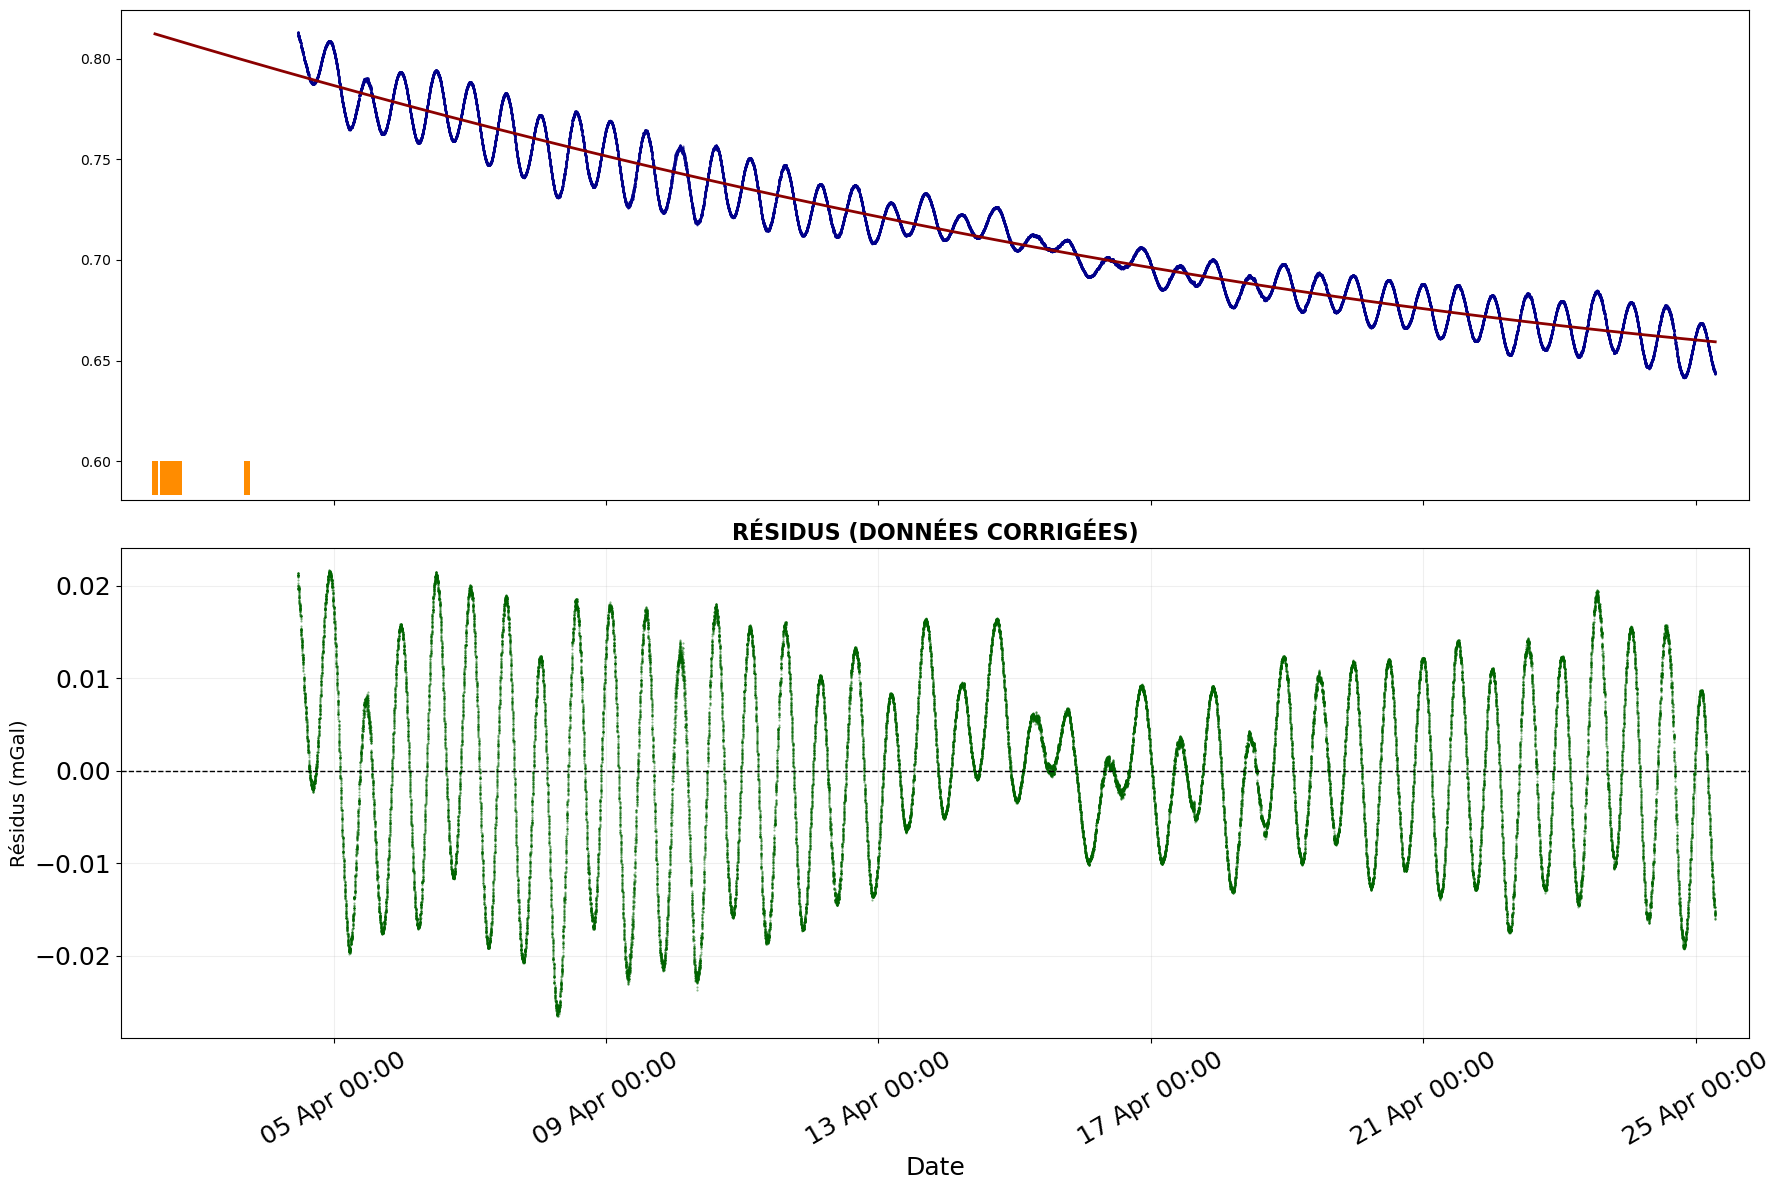

In [3]:
# ==========================================
# CELLULE : FIT POLYNOMIAL (2nd DEGRÉ) - AVRIL (File 0 + Survey Anchor)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.dates as mdates

# 1. PRÉPARATION DES DONNÉES (On utilise le File 0 pour définir la dérive)
df_april_fit = data_blocks[0].copy()

# 2. DÉFINITION DU T_START (Ancrage sur le début du Survey d'Avril)
# On récupère les points de survey du 2-3 Avril
mask_s_dates = (G_survey['datetime'] >= '2024-04-02') & (G_survey['datetime'] <= '2024-04-04')
survey_april = G_survey.loc[mask_s_dates]

if survey_april.empty:
    print("⚠️ Attention : Aucun point de survey trouvé pour fixer t_start. Utilisation du début du fichier 0.")
    t_start = df_april_fit['datetime'].min()
else:
    t_start = survey_april['datetime'].min()

# 3. CALCUL DU TEMPS ÉCOULÉ (en secondes depuis le Survey)
df_april_fit['t_seconds'] = (df_april_fit['datetime'] - t_start).dt.total_seconds()

X = df_april_fit['t_seconds'].values
y = df_april_fit['G_corr'].values # On utilise G_final issu de l'alignement

# 4. CALCUL DU MODÈLE POLYNOMIAL (ORDRE 2)
coeffs = np.polyfit(X, y, 2)
p = np.poly1d(coeffs)
y_trend_poly2 = p(X)

# 5. INDICATEURS DE PERFORMANCE
r2_p2 = r2_score(y, y_trend_poly2)
rmse_p2 = np.sqrt(mean_squared_error(y, y_trend_poly2))
# Dérive moyenne par jour
pente_moyenne = (p(X[-1]) - p(X[0])) / ((X[-1] - X[0]) / 86400)

# 6. APPLICATION DE LA CORRECTION (Résidus)
df_april_fit['G_no_drift_poly2'] = y - y_trend_poly2

# 7.Save stats
# Initialisation du dictionnaire si besoin
modeles_derive = {} if 'modeles_derive' not in locals() else modeles_derive
# Stockage avec TOUS les indicateurs pour le tableau récapitulatif
modeles_derive['april'] = {
    'coeffs': coeffs,        # Le vecteur [a, b, c]
    't_start': t_start,      # La date de référence
    'rmse': rmse_p2,        # Ta variable de précision
    'r2': r2_p2,            # Ton coefficient R²
    'drift': pente_moyenne # Ta dérive en mGal/jour
}
    
print(f"--- RÉSULTATS AVRIL (Basé sur File 0) ---")
print(f"t_start (Ancrage Survey) : {t_start}")
print(f"Précision (RMSE) : {rmse_p2:.6f} mGal")
print(f"Coefficient R² : {r2_p2:.6f}")
print(f"Formule : G(t) = ({coeffs[0]:.6e})*t² + ({coeffs[1]:.6e})*t + {coeffs[2]:.6f}")
print(f"Dérive moyenne sur la période : {pente_moyenne:.5f} mGal/jour")

# 8. PLOT DE VÉRIFICATION
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# --- Graphique 1 : Données + Trend (avec extension vers le Survey) ---
ax1.plot(df_april_fit['datetime'], y, 'o', markersize=0.5, color='darkblue', alpha=0.3, label='Données Basement (File 0)')

# --- Graphique 1 : Données + Trend EXTRAPOLÉ ---
ax1.plot(df_april_fit['datetime'], y, 'o', markersize=0.5, color='darkblue', alpha=0.3, label='Données Basement (File 0)')

# --- NOUVELLE LOGIQUE POUR LE TRAIT DU FIT ---
# 1. On crée un vecteur de temps qui part de 0 (t_start) jusqu'à la fin du fichier 0
t_final = df_april_fit['t_seconds'].max()
t_trace = np.linspace(0, t_final, 1000) # 1000 points pour une courbe bien lisse

# 2. On calcule les dates correspondantes pour l'axe X
dates_trace = [t_start + pd.Timedelta(seconds=s) for s in t_trace]

# 3. On calcule les valeurs Y avec le polynôme
y_trace = p(t_trace)

# 4. On trace le trait qui commence maintenant au 2 Avril
ax1.plot(dates_trace, y_trace, color='darkred', linewidth=2, label='Trend Poly Extrapolé (Ordre 2)')
# ----------------------------------------------

# Ajout de la Timeline Survey (Orange)
if not survey_april.empty:
    pos_y_survey = y.min() - 0.05
    ax1.plot(survey_april['datetime'], [pos_y_survey] * len(survey_april), '|', 
             markersize=25, mew=4, color='darkorange', label='Périodes Survey (2-3 Avril)')

# --- Graphique 2 : Résidus ---
ax2.plot(df_april_fit['datetime'], df_april_fit['G_no_drift_poly2'], 'o', markersize=0.5, color='darkgreen', alpha=0.5)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title("RÉSIDUS (DONNÉES CORRIGÉES)", fontsize=16, fontweight='bold')
ax2.set_ylabel("Résidus (mGal)", fontsize=14)
ax2.set_xlabel("Date", fontsize=18)
ax2.grid(True, alpha=0.2)

# --- FORMATAGE DES DATES ---
# On force l'axe X pour inclure le Survey
ax1.set_xlim(t_start - pd.Timedelta(hours=12), df_april_fit['datetime'].max() + pd.Timedelta(hours=12))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=30, fontsize=18)
plt.yticks(fontsize=18)

plt.tight_layout()
plt.show()

## SURVEY 2 - MAY (3-10)

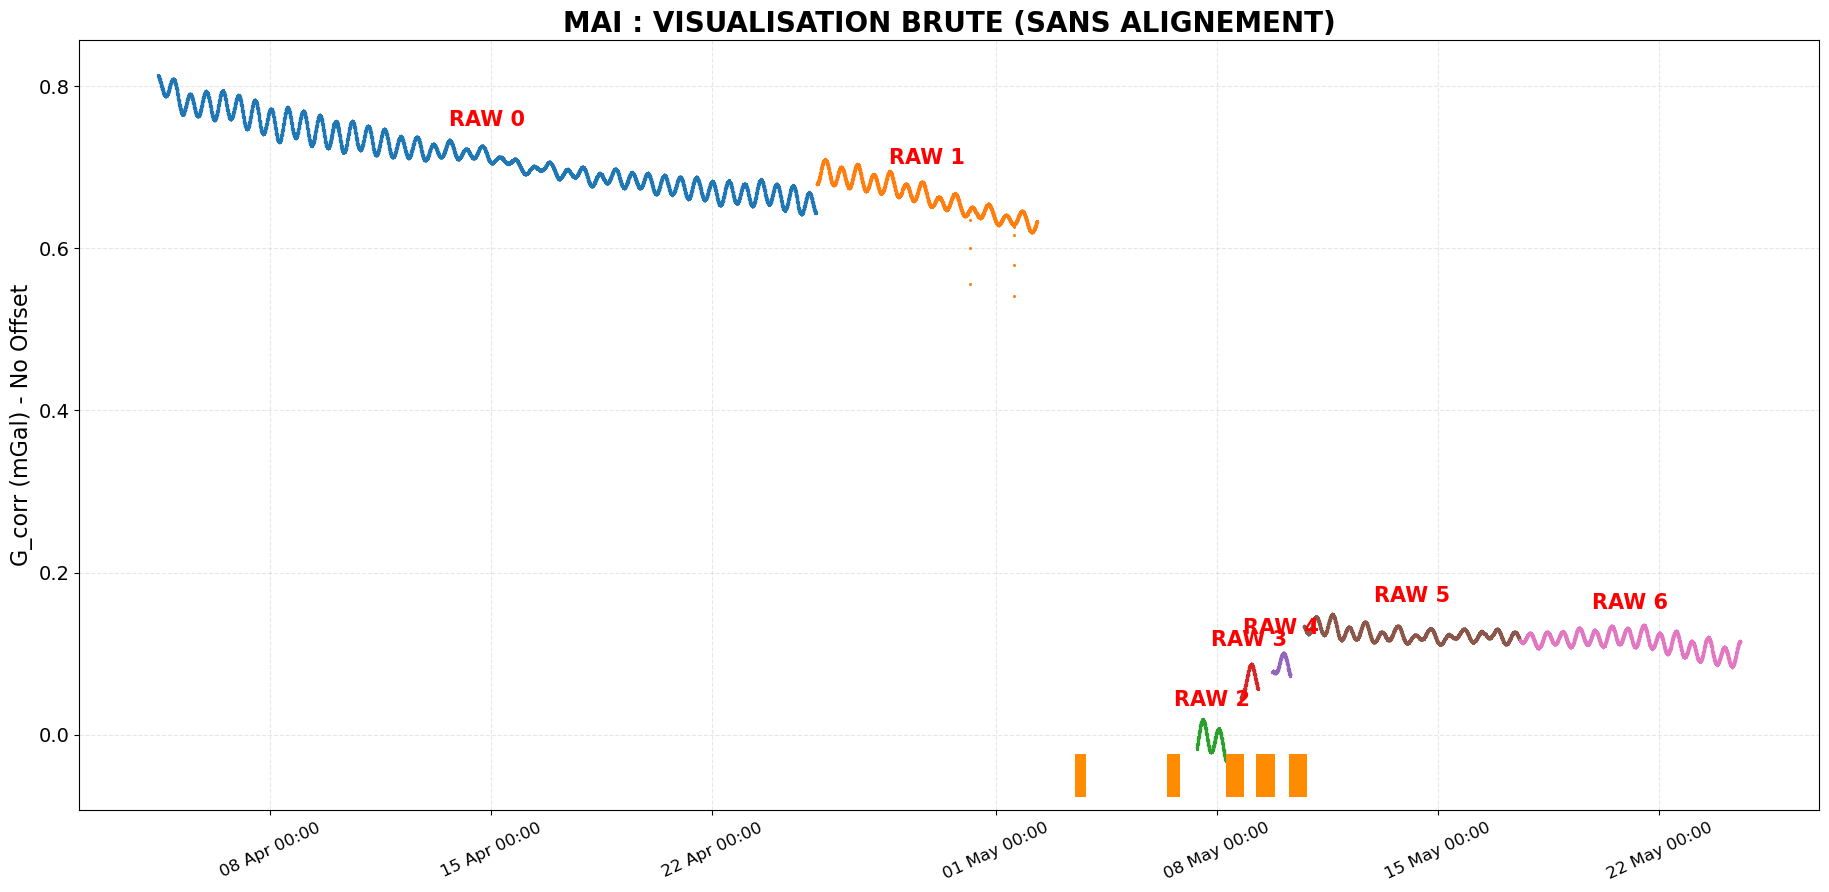

In [4]:
# ==========================================
# CELLULE 1 : VISUALISATION RAW - MAI (0 à 6)
# ==========================================
import matplotlib.dates as mdates

# On définit les indices pour Mai
indices_mai = [0, 1, 2, 3, 4, 5, 6]
plt.figure(figsize=(20, 10))

# 1. TRACÉ DES DONNÉES SANS AUCUN OFFSET
for idx in indices_mai:
    # On récupère le bloc original (G_corr uniquement)
    df_raw = data_blocks[idx].copy()
    
    plt.plot(df_raw['datetime'], df_raw['G_corr'], 'o', markersize=1.2, label=f'File {idx} (Raw)')
    
    # Repère visuel pour l'ID (placé un peu au-dessus de la médiane du bloc)
    mid_time = df_raw['datetime'].iloc[len(df_raw)//2]
    plt.text(mid_time, df_raw['G_corr'].median() + 0.04, f"RAW {idx}", 
             color='red', fontsize=15, fontweight='bold', ha='center')

# 2. TIMELINE SURVEY (Orange)
# On filtre le survey pour la période globale de Mai
mask_s = (G_survey['datetime'] >= data_blocks[0]['datetime'].min()) & \
         (G_survey['datetime'] <= data_blocks[6]['datetime'].max())
survey_mai = G_survey.loc[mask_s]

if not survey_mai.empty:
    # Placé à -0.05 pour être sous les données
    plt.plot(survey_mai['datetime'], [-0.05] * len(survey_mai), '|', 
             markersize=30, mew=5, color='darkorange', label='Survey Timeline')

# 3. MISE EN FORME
plt.title("MAI : VISUALISATION BRUTE (SANS ALIGNEMENT)", fontsize=20, fontweight='bold')
plt.ylabel("G_corr (mGal) - No Offset", fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--')
# plt.legend(loc='upper left', fontsize=10, markerscale=5) # Optionnel si trop de labels

# ... (ton code précédent)

# Formatage des dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=25, fontsize=12) # Rotation réduite et police plus petite
plt.yticks(fontsize=14)
#plt.ylim(-0.06, 0.25) 

# AJUSTEMENT MANUEL DES MARGES
plt.subplots_adjust(bottom=0.15, top=0.92, left=0.08, right=0.95)

plt.show()

### 1. Offset and cleaning

📊 RÉCAPITULATIF DES OFFSETS APPLIQUÉS (MAI) :
--------------------------------------------------
File 0 : Offset Total = +0.000000 mGal (Auto uniquement)
File 1 : Offset Total = -0.035769 mGal (Auto uniquement)
File 5 : Offset Total = +0.418689 mGal (Manuel: -0.0450)
File 6 : Offset Total = +0.420562 mGal (Auto uniquement)
--------------------------------------------------


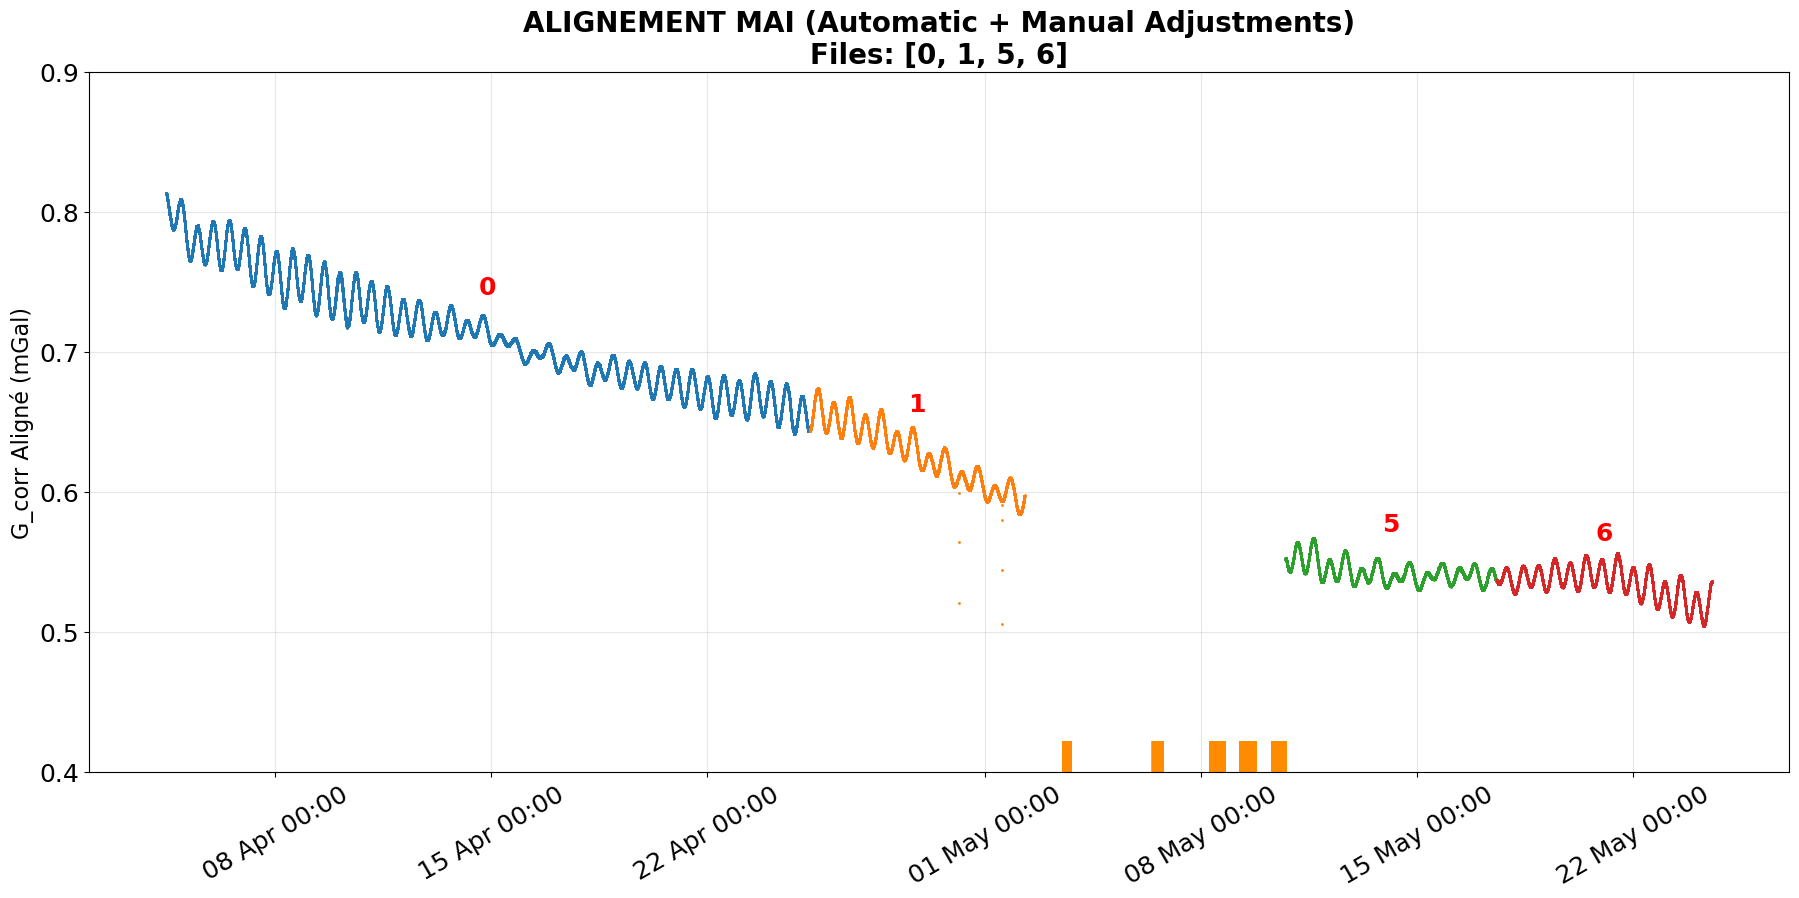

In [5]:
# ==========================================
# CELLULE 2 : SURVEY MAI (Files 0, 1, 5, 6)
# ==========================================

# 1. TON TABLEAU DE BORD POUR LES AJUSTEMENTS MANUELS
ajustements_mai = {0: 0.0, 1: 0.0, 5: -0.045, 6: 0.0}

# 2. CALCUL DE L'ALIGNEMENT AUTOMATIQUE (Médiane)
indices_mai = [0, 1, 5, 6]
mai_blocks = []
current_offset = 0
offsets_appliques = {} # Dictionnaire pour stocker les résultats

for i, idx in enumerate(indices_mai):
    df = data_blocks[idx].copy()
    
    if i > 0:
        # Calcul de la marche entre la fin du bloc précédent et le début du nouveau
        val_end_prev = mai_blocks[i-1]['G_corr'].tail(10).median()
        val_start_curr = df['G_corr'].head(10).median()
        
        # Calcul du saut automatique + ton ajustement manuel
        step_auto = val_end_prev - val_start_curr
        current_offset += (step_auto + ajustements_mai[idx])
        
    df['G_final_mai'] = df['G_corr'] + current_offset
    mai_blocks.append(df)
    offsets_appliques[idx] = current_offset # On enregistre l'offset total pour ce fichier

# Fusion pour le plot
df_mai_total = pd.concat(mai_blocks, ignore_index=True)

# --- NOUVEAU : AFFICHAGE DES OFFSETS DANS LA CONSOLE ---
print(f"📊 RÉCAPITULATIF DES OFFSETS APPLIQUÉS (MAI) :")
print("-" * 50)
for idx, off in offsets_appliques.items():
    type_ajust = f"(Manuel: {ajustements_mai[idx]:+.4f})" if ajustements_mai[idx] != 0 else "(Auto uniquement)"
    print(f"File {idx} : Offset Total = {off:+.6f} mGal {type_ajust}")
print("-" * 50)

# ---------------------------------------------------------
# 3. PLOT DE VÉRIFICATION (AVEC TIMELINE ORANGE)
# ---------------------------------------------------------
plt.figure(figsize=(20, 10))

# --- BASEMENT (Fichiers 0, 1, 5, 6) ---
for idx in indices_mai:
    block = df_mai_total[df_mai_total['file_index'] == idx]
    plt.plot(block['datetime'], block['G_final_mai'], 'o', markersize=1, label=f'File {idx}')
    
    # Repères ID en rouge
    mid_time = block['datetime'].iloc[len(block)//2]
    plt.text(mid_time, block['G_final_mai'].median() + 0.03, f"{idx}", 
             color='red', fontsize=18, fontweight='bold', ha='center')

# --- TIMELINE SURVEY (Orange en bas) ---
mask_s = (G_survey['datetime'] >= df_mai_total['datetime'].min()) & \
         (G_survey['datetime'] <= df_mai_total['datetime'].max())
survey_mai = G_survey.loc[mask_s]

if not survey_mai.empty:
    plt.plot(survey_mai['datetime'], [0.41] * len(survey_mai), '|', 
             markersize=25, mew=4, color='darkorange')

# --- LÉGENDE ET MISE EN FORME ---
plt.title(f"ALIGNEMENT MAI (Automatic + Manual Adjustments)\nFiles: {indices_mai}", fontsize=20, fontweight='bold')
plt.ylabel("G_corr Aligné (mGal)", fontsize=16)
plt.ylim(0.4, 0.9)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=30, fontsize=18)
plt.yticks(fontsize=18)

# Correction du warning tight_layout
plt.subplots_adjust(bottom=0.2, top=0.9, left=0.1, right=0.95)

plt.show()

### 2. Trend and residue calculation

#### Second order polynomial a2 + bx + c

BEST FIT file 0156 : with offset -0.03 (or so)
BEST FIT file 156 : with offset -0.065

--- RÉSULTATS MAI (STOP 17/05 00h) ---
Fichiers inclus : [1 5]
Précision (RMSE) : 0.007928 mGal
Coefficient R² : 0.969227
Formule : G(t) = (3.794260e-14)*t² + (-1.367833e-07)*t + 0.664331
Dérive moyenne sur la période : -0.00568 mGal/jour


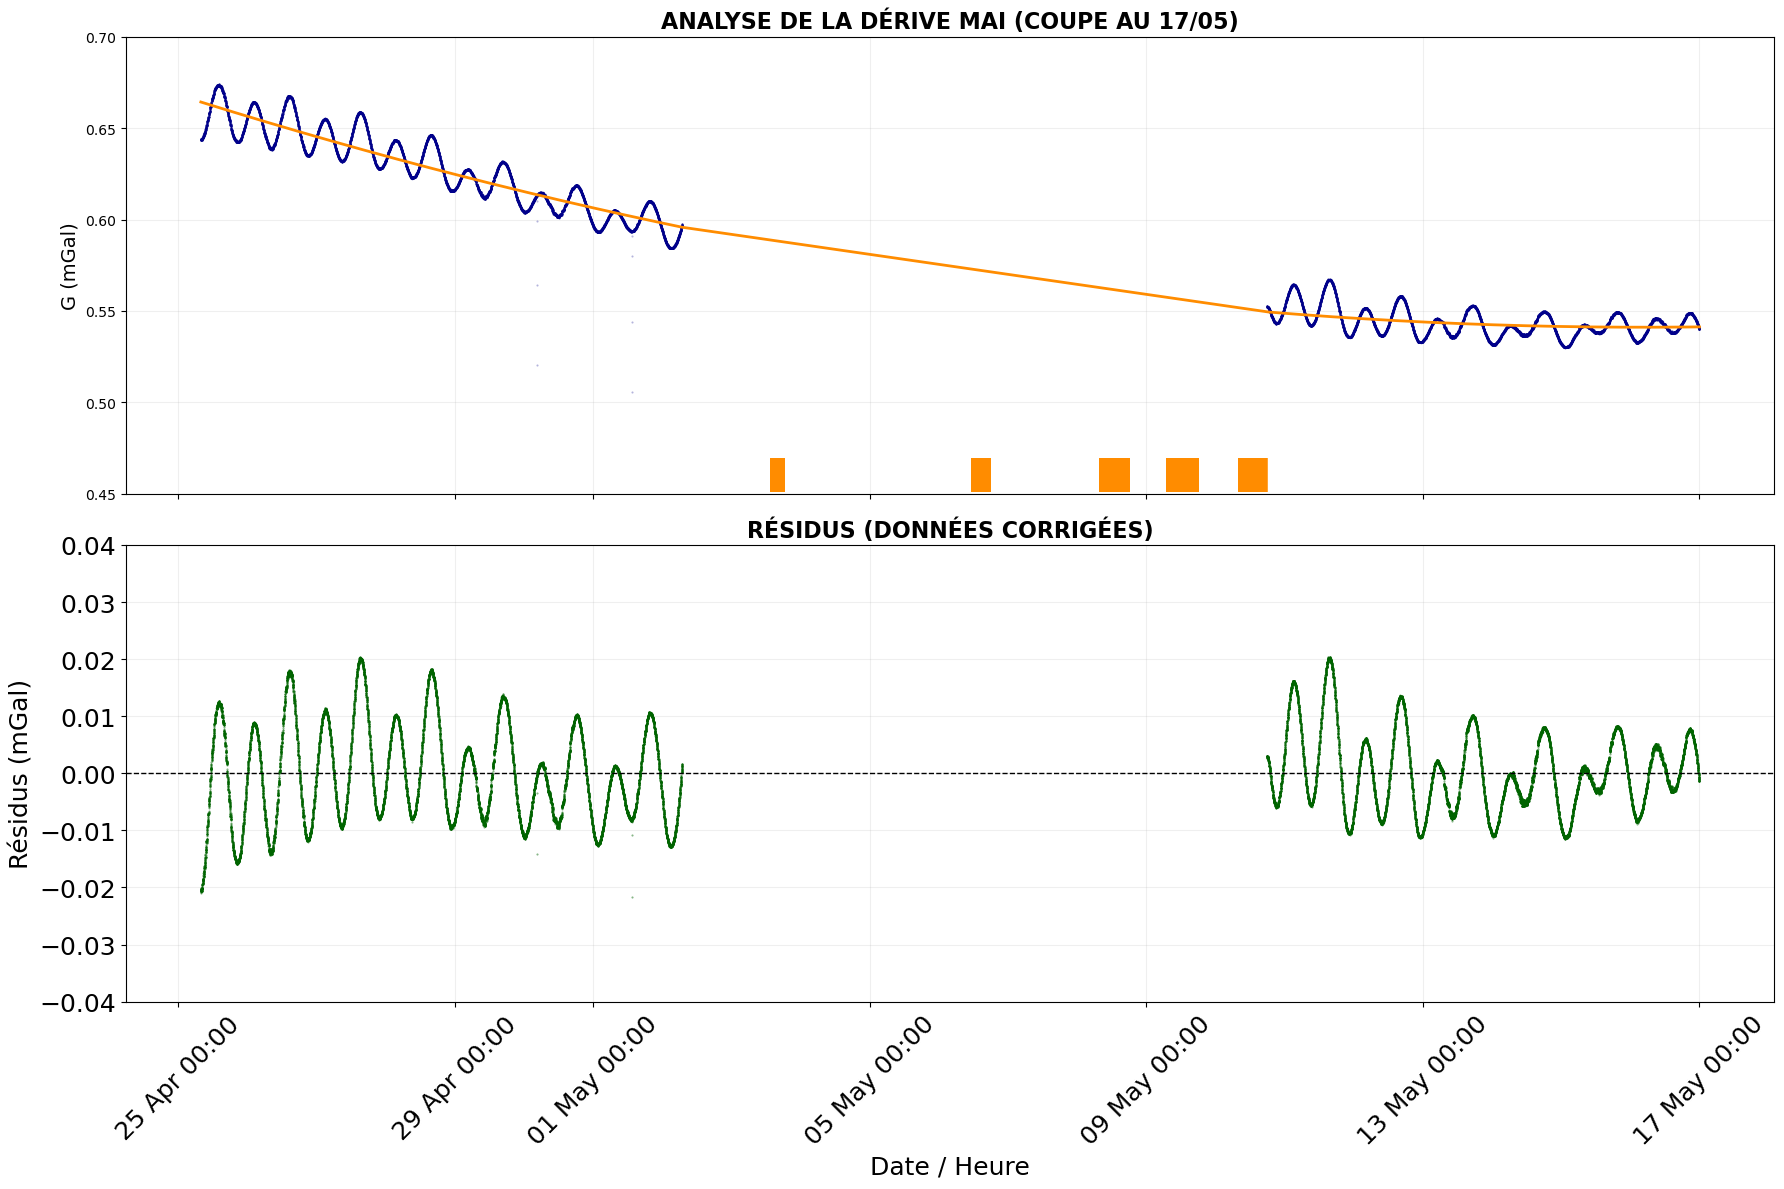

In [6]:
# ==========================================
# CELLULE 3 : FIT POLYNOMIAL (2nd DEGRÉ) - MAI (STOP 17/05 00h)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.dates as mdates

# 1. FILTRAGE : Exclure le File 0 ET limiter au 17 mai 00h
date_cut_mai = '2024-05-17 00:00:00'
df_mai_filtre = df_mai_total[
    (df_mai_total['file_index'] != 0) & 
    (df_mai_total['datetime'] <= date_cut_mai)
].copy()

# 2. PRÉPARATION DES DONNÉES
t_start = df_mai_filtre['datetime'].min()
df_mai_filtre['t_seconds'] = (df_mai_filtre['datetime'] - t_start).dt.total_seconds()

X = df_mai_filtre['t_seconds'].values
y = df_mai_filtre['G_final_mai'].values

# 3. CALCUL DU MODÈLE POLYNOMIAL (ORDRE 2)
coeffs = np.polyfit(X, y, 2)
p = np.poly1d(coeffs)
y_trend_poly2 = p(X)

# 4. INDICATEURS DE PERFORMANCE
r2_p2 = r2_score(y, y_trend_poly2)
rmse_p2 = np.sqrt(mean_squared_error(y, y_trend_poly2))

# Calcul de la dérive moyenne sur la fenêtre restreinte
pente_moyenne = (p(X[-1]) - p(X[0])) / ((X[-1] - X[0]) / 86400)

# 5. APPLICATION DE LA CORRECTION (Visualisation des résidus)
df_mai_filtre['G_no_drift_poly2'] = y - y_trend_poly2

# 7.Save stats
# Initialisation du dictionnaire si besoin
modeles_derive = {} if 'modeles_derive' not in locals() else modeles_derive
# Stockage avec TOUS les indicateurs pour le tableau récapitulatif
modeles_derive['may'] = {
    'coeffs': coeffs,        # Le vecteur [a, b, c]
    't_start': t_start,      # La date de référence
    'rmse': rmse_p2,        # Ta variable de précision
    'r2': r2_p2,            # Ton coefficient R²
    'drift': pente_moyenne # Ta dérive en mGal/jour
}

print(f"--- RÉSULTATS MAI (STOP 17/05 00h) ---")
print(f"Fichiers inclus : {df_mai_filtre['file_index'].unique()}")
print(f"Précision (RMSE) : {rmse_p2:.6f} mGal")
print(f"Coefficient R² : {r2_p2:.6f}")
print(f"Formule : G(t) = ({coeffs[0]:.6e})*t² + ({coeffs[1]:.6e})*t + {coeffs[2]:.6f}")
print(f"Dérive moyenne sur la période : {pente_moyenne:.5f} mGal/jour")

# 7. PLOT DE VÉRIFICATION
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# --- Graphique 1 : Données alignées + Courbe 2nd degré ---
ax1.plot(df_mai_filtre['datetime'], y, 'o', markersize=0.5, color='darkblue', alpha=0.3, label='Données (Stop 17/05)')
ax1.plot(df_mai_filtre['datetime'], y_trend_poly2, color='darkorange', linewidth=2, label='Trend Poly (Ordre 2)')

# Ajout de la Timeline Survey
mask_s = (G_survey['datetime'] >= df_mai_filtre['datetime'].min()) & \
         (G_survey['datetime'] <= df_mai_filtre['datetime'].max())
survey_mai = G_survey.loc[mask_s]

if not survey_mai.empty:
    ax1.plot(survey_mai['datetime'], [0.46] * len(survey_mai), '|', 
             markersize=25, mew=4, color='darkorange', label='Périodes Survey')

ax1.set_title("ANALYSE DE LA DÉRIVE MAI (COUPE AU 17/05)", fontsize=16, fontweight='bold')
ax1.set_ylabel("G (mGal)", fontsize=14)
ax1.grid(True, alpha=0.2)
ax1.set_ylim(0.45, 0.7) 
#ax1.legend(loc='upper right', markerscale=10)

# --- Graphique 2 : Résidus ---
ax2.plot(df_mai_filtre['datetime'], df_mai_filtre['G_no_drift_poly2'], 'o', markersize=0.5, color='darkgreen', alpha=0.5)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title("RÉSIDUS (DONNÉES CORRIGÉES)", fontsize=16, fontweight='bold')
ax2.set_ylim(-0.04, 0.04)
ax2.set_ylabel("Résidus (mGal)", fontsize=18)
ax2.set_xlabel("Date / Heure", fontsize=18)
ax2.grid(True, alpha=0.2)

# --- FORMATAGE DES DATES ---
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=45, fontsize=18)
plt.yticks(fontsize=18)

plt.tight_layout()
plt.show()

## SURVEY 3 - 3 JUNE

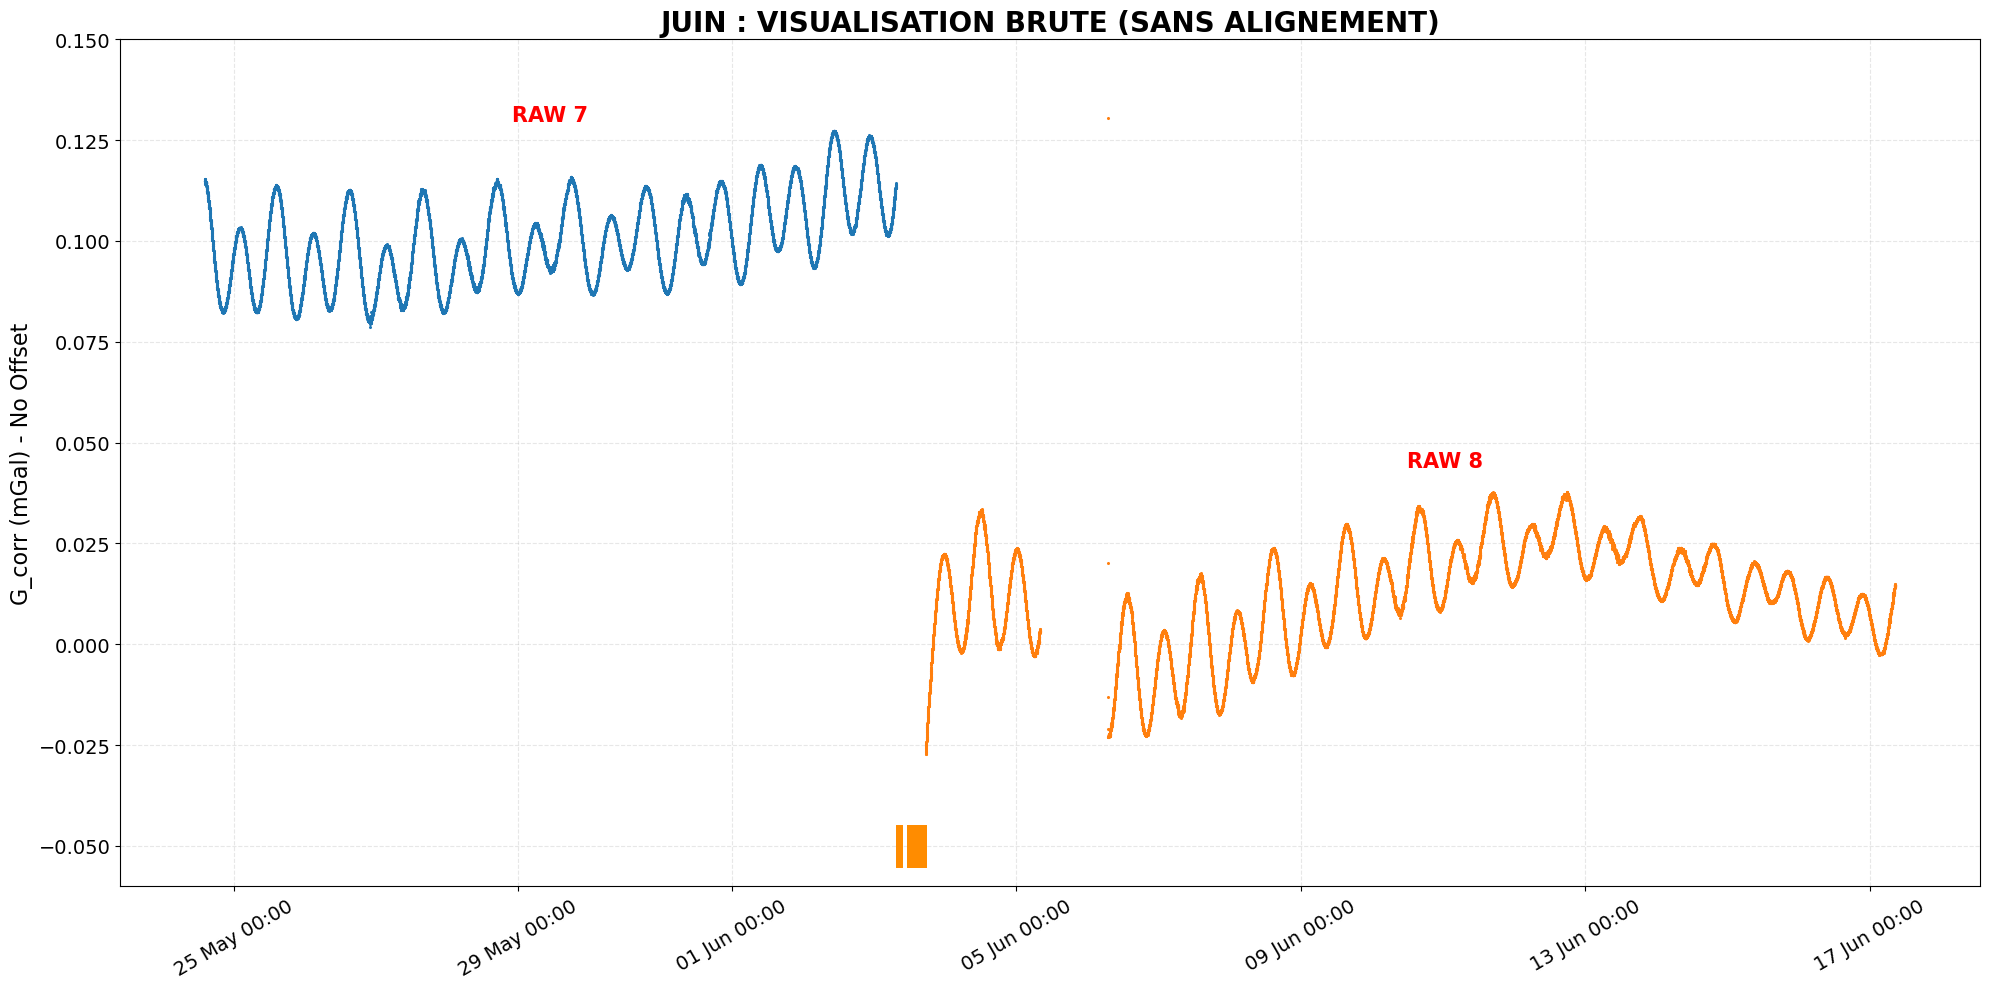

ℹ️ Le saut naturel entre le File 7 et le File 8 est de : -0.140570 mGal


In [7]:
# ==========================================
# CELLULE 1 : VISUALISATION RAW - JUIN (7, 8)
# ==========================================

indices_juin = [7, 8]
plt.figure(figsize=(20, 10))

# 1. TRACÉ DES DONNÉES SANS AUCUN OFFSET
for idx in indices_juin:
    # On récupère le bloc original (G_corr uniquement)
    df_raw = data_blocks[idx].copy()
    
    plt.plot(df_raw['datetime'], df_raw['G_corr'], 'o', markersize=1.2, label=f'File {idx} (Raw G_corr)')
    
    # Repère visuel pour l'ID
    mid_time = df_raw['datetime'].iloc[len(df_raw)//2]
    plt.text(mid_time, df_raw['G_corr'].median() + 0.03, f"RAW {idx}", 
             color='red', fontsize=15, fontweight='bold', ha='center')

# 2. TIMELINE SURVEY (Orange)
mask_s = (G_survey['datetime'] >= data_blocks[7]['datetime'].min()) & \
         (G_survey['datetime'] <= data_blocks[8]['datetime'].max())
survey_juin = G_survey.loc[mask_s]

if not survey_juin.empty:
    # On ajuste le Y du survey pour qu'il soit visible par rapport aux données raw
    plt.plot(survey_juin['datetime'], [-0.05] * len(survey_juin), '|', 
             markersize=30, mew=5, color='darkorange', label='Survey Timeline')

# 3. MISE EN FORME
plt.title("JUIN : VISUALISATION BRUTE (SANS ALIGNEMENT)", fontsize=20, fontweight='bold')
plt.ylabel("G_corr (mGal) - No Offset", fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--')
#plt.legend(loc='upper left', fontsize=12)

# Formatage des dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=30, fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(-0.06, 0.15)

plt.tight_layout()
plt.show()

# 4. CALCUL DU SAUT REEL (INFO CONSOLE)
gap = data_blocks[8]['G_corr'].head(10).median() - data_blocks[7]['G_corr'].tail(10).median()
print(f"ℹ️ Le saut naturel entre le File 7 et le File 8 est de : {gap:.6f} mGal")

### 1. Offset and cleaning

✅ Offset total appliqué au File 8 : 0.135807 mGal


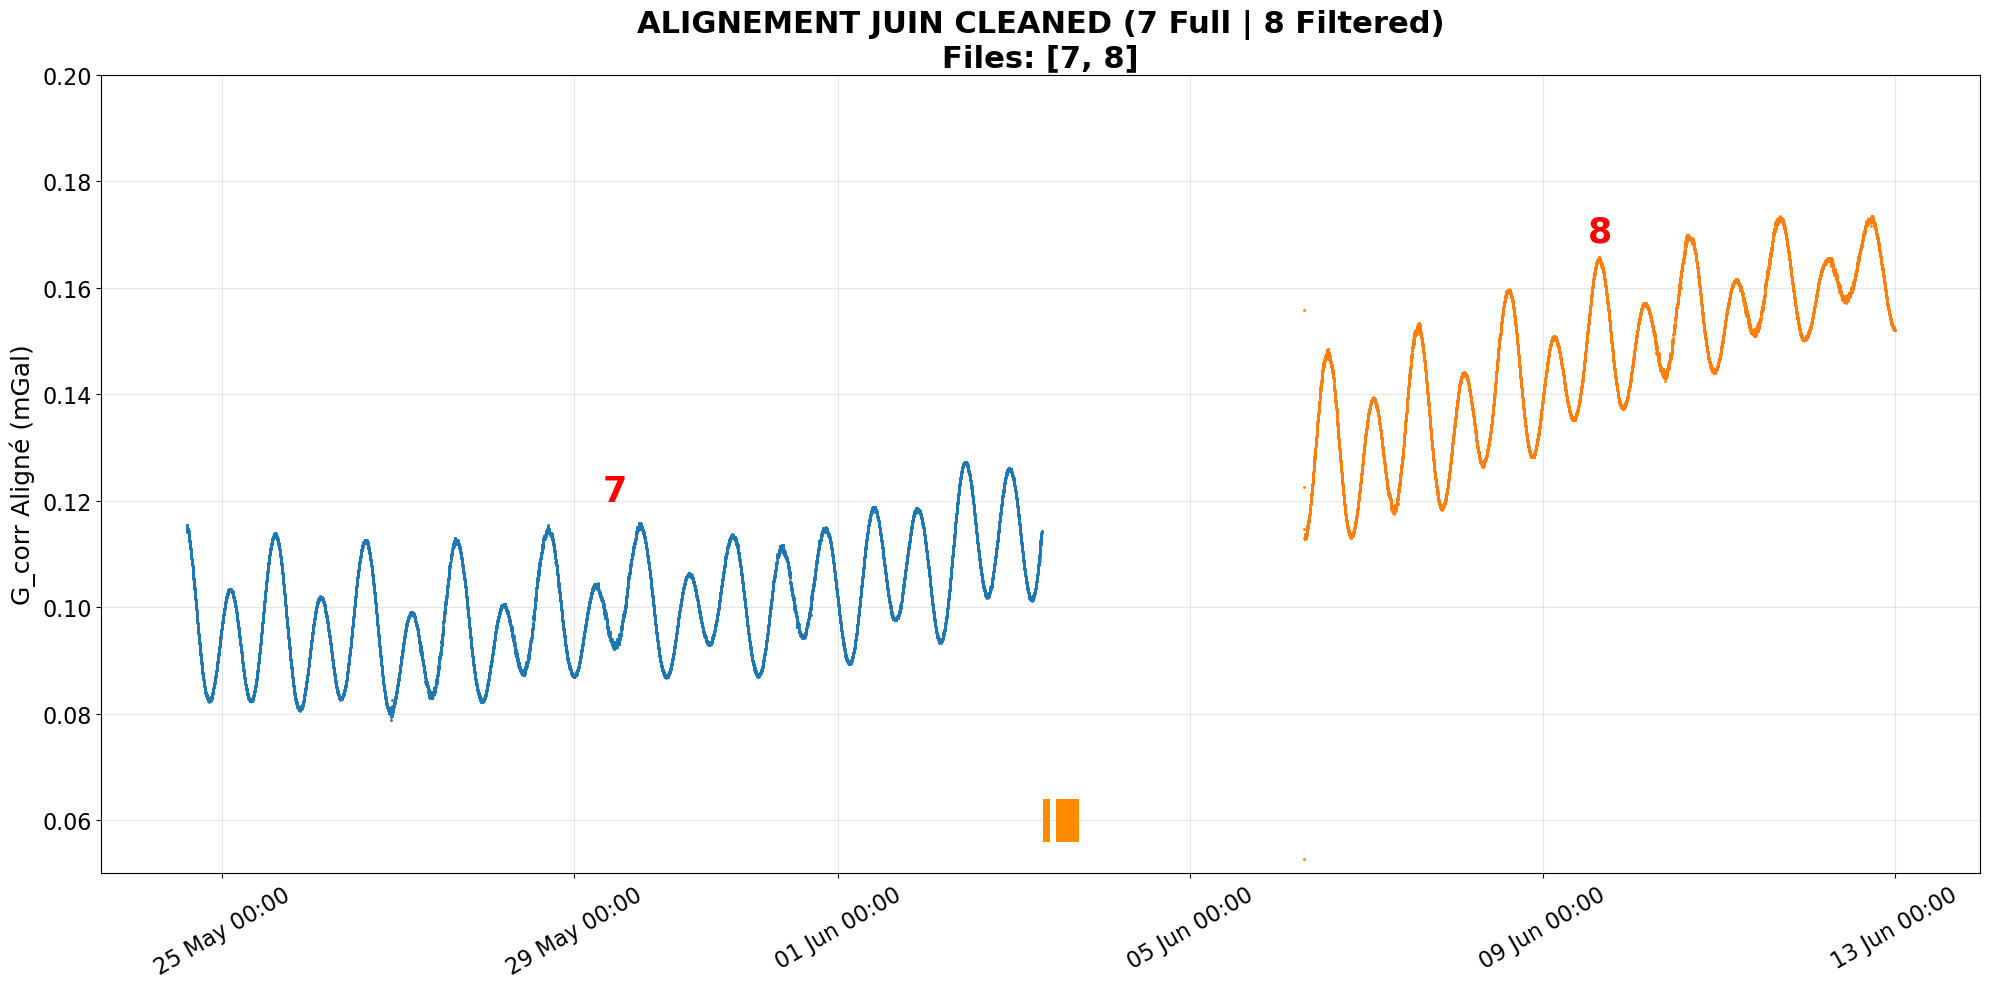

In [8]:
# ==========================================
# CELLULE 2 : SURVEY JUIN (Files 7, 8 CLEANED)
# ==========================================

# 1. TON TABLEAU DE BORD POUR LES AJUSTEMENTS MANUELS
ajustements_juin = {7: 0.0, 8: 0.0}
#ajustements_juin[8] = 0.01 

# 2. CALCUL DE L'ALIGNEMENT AVEC FILTRAGE INTÉGRÉ
indices_juin = [7, 8]
juin_blocks = []
current_offset = 0

for i, idx in enumerate(indices_juin):
    # Récupération de la base (G_corr)
    df = data_blocks[idx].copy()
    
    # --- NETTOYAGE SPÉCIFIQUE AU FILE 8 ---
    if idx == 8:
        # On garde uniquement entre le 6 juin 07:02:30 et le 13 juin minuit
        mask_8 = (df['datetime'] >= '2024-06-06 07:02:30') & \
                 (df['datetime'] <= '2024-06-13 00:00:00')
        df = df[mask_8].copy()
    
    # --- CALCUL DE L'ALIGNEMENT ---
    if i > 0 and not df.empty:
        # Médiane sur la jonction (20 points pour plus de stabilité)
        val_end_prev = juin_blocks[i-1]['G_corr'].tail(20).median()
        val_start_curr = df['G_corr'].head(20).median()
        
        step_offset = val_end_prev - val_start_curr
        current_offset += (step_offset + ajustements_juin[idx])
        print(f"✅ Offset total appliqué au File 8 : {current_offset:.6f} mGal")
        
    df['G_final_juin'] = df['G_corr'] + current_offset
    juin_blocks.append(df)

# Fusion finale du bloc de Juin
df_juin_total = pd.concat(juin_blocks, ignore_index=True)

# ---------------------------------------------------------
# 3. PLOT DE VÉRIFICATION (AVEC TIMELINE ORANGE)
# ---------------------------------------------------------
plt.figure(figsize=(20, 10))

# --- BASEMENT (Fichiers 7 et 8 Clean) ---
for idx in indices_juin:
    block = df_juin_total[df_juin_total['file_index'] == idx]
    if not block.empty:
        plt.plot(block['datetime'], block['G_final_juin'], 'o', markersize=1, label=f'File {idx}')
        
        # Repères ID
        mid_time = block['datetime'].iloc[len(block)//2]
        plt.text(mid_time, block['G_final_juin'].median() + 0.02, f"{idx}", 
                 color='red', fontsize=25, fontweight='bold', ha='center')

# --- TIMELINE SURVEY (Orange en bas) ---
mask_s = (G_survey['datetime'] >= df_juin_total['datetime'].min()) & \
         (G_survey['datetime'] <= df_juin_total['datetime'].max())
survey_juin = G_survey.loc[mask_s]

if not survey_juin.empty:
    # Placé à 0.06 comme tu l'as demandé
    plt.plot(survey_juin['datetime'], [0.06] * len(survey_juin), '|', 
             markersize=30, mew=5, color='darkorange')

# --- LÉGENDE ET MISE EN FORME ---
plt.plot([], [], 'o', markersize=10, color='blue', label='Basement')
plt.plot([], [], '|', markersize=15, mew=3, color='darkorange', label='Périodes Survey')

plt.title(f"ALIGNEMENT JUIN CLEANED (7 Full | 8 Filtered)\nFiles: {indices_juin}", fontsize=22, fontweight='bold')
plt.ylabel("G_corr Aligné (mGal)", fontsize=18)
plt.ylim(0.05, 0.2) 
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=30, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()

--- RÉSULTATS JUIN (7 FULL & 8 CUT) ---
Fichiers inclus : [7 8]
Précision (RMSE) : 0.009321 mGal
Coefficient R² : 0.873537
Formule de la dérive : G(t) = (2.601653e-14)*t² + (1.668894e-09)*t + 0.093680
Dérive moyenne sur la période : 0.00391 mGal/jour


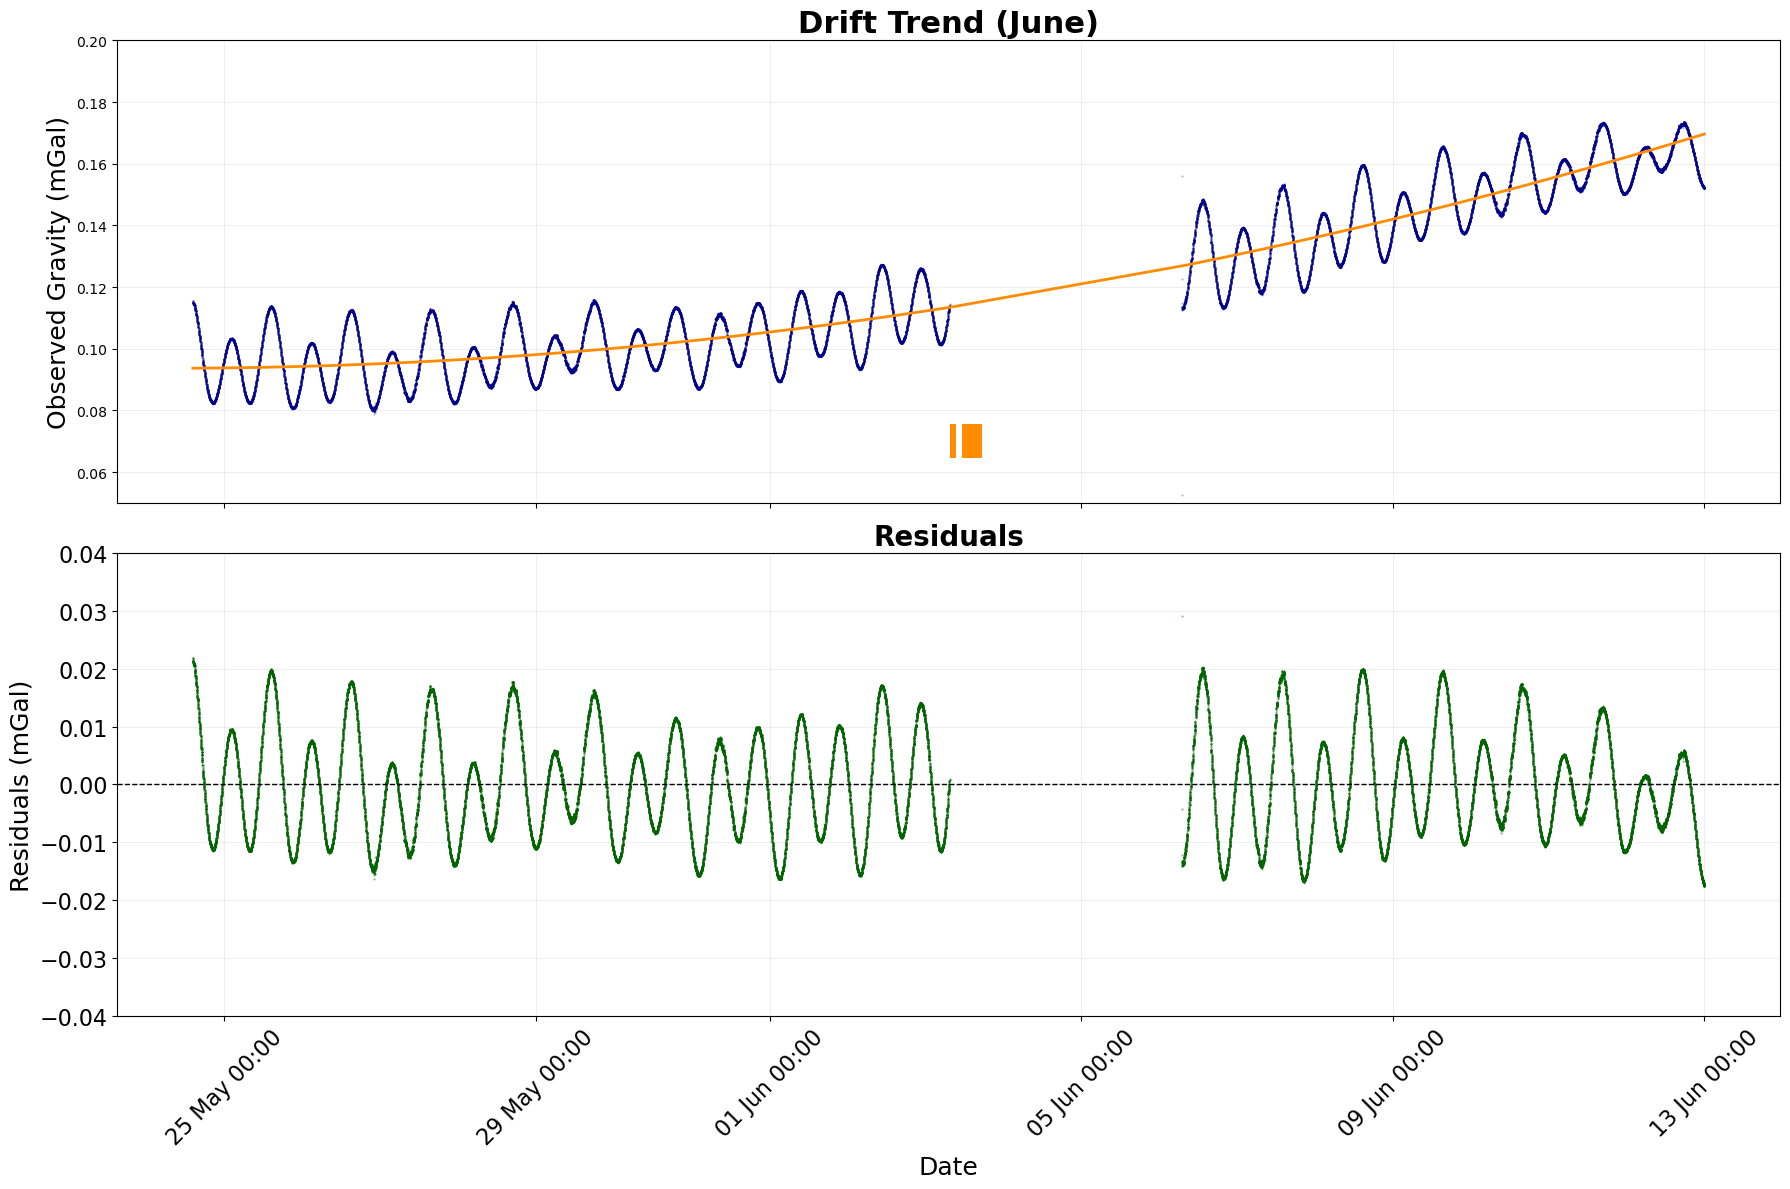

In [9]:
# ==========================================
# CELLULE 3 : FIT POLYNOMIAL (2nd DEGRÉ) - JUIN
# ==========================================
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.dates as mdates

# 1. PRÉPARATION DES DONNÉES (On utilise le df cleané de Juin)
df_juin_filtre = df_juin_total.copy()
t_start = df_juin_filtre['datetime'].min()
df_juin_filtre['t_seconds'] = (df_juin_filtre['datetime'] - t_start).dt.total_seconds()

X = df_juin_filtre['t_seconds'].values
y = df_juin_filtre['G_final_juin'].values

# 2. CALCUL DU MODÈLE POLYNOMIAL (ORDRE 2)
coeffs = np.polyfit(X, y, 2)
p = np.poly1d(coeffs)
y_trend_poly2 = p(X)

# 3. INDICATEURS DE PERFORMANCE
r2_p2 = r2_score(y, y_trend_poly2)
rmse_p2 = np.sqrt(mean_squared_error(y, y_trend_poly2))

# 4. APPLICATION DE LA CORRECTION
df_juin_filtre['G_no_drift_poly2'] = y - y_trend_poly2

# 5. AFFICHAGE DES RÉSULTATS
print(f"--- RÉSULTATS JUIN (7 FULL & 8 CUT) ---")
print(f"Fichiers inclus : {df_juin_filtre['file_index'].unique()}")
print(f"Précision (RMSE) : {rmse_p2:.6f} mGal")
print(f"Coefficient R² : {r2_p2:.6f}")
print(f"Formule de la dérive : G(t) = ({coeffs[0]:.6e})*t² + ({coeffs[1]:.6e})*t + {coeffs[2]:.6f}")

# Calcul de la pente moyenne en mGal/jour
pente_moyenne = (p(X[-1]) - p(X[0])) / ((X[-1] - X[0]) / 86400)
print(f"Dérive moyenne sur la période : {pente_moyenne:.5f} mGal/jour")

# 7.Save stats
# Initialisation du dictionnaire si besoin
modeles_derive = {} if 'modeles_derive' not in locals() else modeles_derive
# Stockage avec TOUS les indicateurs pour le tableau récapitulatif
modeles_derive['june'] = {
    'coeffs': coeffs,        # Le vecteur [a, b, c]
    't_start': t_start,      # La date de référence
    'rmse': rmse_p2,        # Ta variable de précision
    'r2': r2_p2,            # Ton coefficient R²
    'drift': pente_moyenne # Ta dérive en mGal/jour
}

# 6. PLOT DE VÉRIFICATION
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# --- Graphique 1 : Données alignées + Courbe 2nd degré ---
ax1.plot(df_juin_filtre['datetime'], y, 'o', markersize=0.5, color='darkblue', alpha=0.3, label='Données (7, 8 clean)')
ax1.plot(df_juin_filtre['datetime'], y_trend_poly2, color='darkorange', linewidth=2, label='Trend Poly (Ordre 2)')

# Ajout de la Timeline Survey (Traits orange)
mask_s = (G_survey['datetime'] >= df_juin_filtre['datetime'].min()) & \
         (G_survey['datetime'] <= df_juin_filtre['datetime'].max())
survey_juin = G_survey.loc[mask_s]

if not survey_juin.empty:
    # Placé à 0.07 pour être visible sur l'échelle de Juin
    ax1.plot(survey_juin['datetime'], [0.07] * len(survey_juin), '|', 
             markersize=25, mew=4, color='darkorange', label='Périodes Survey')

ax1.set_title("Drift Trend (June)", fontsize=22, fontweight='bold')
ax1.set_ylabel("Observed Gravity (mGal)", fontsize=18)
ax1.grid(True, alpha=0.2)
ax1.set_ylim(0.05, 0.2) # Ajusté pour Juin

# --- Graphique 2 : Résidus ---
ax2.plot(df_juin_filtre['datetime'], df_juin_filtre['G_no_drift_poly2'], 'o', markersize=0.5, color='darkgreen', alpha=0.5)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title("Residuals", fontsize=20, fontweight='bold')

# Limites des résidus pour voir les petites variations
ax2.set_ylim(-0.04, 0.04) 
ax2.set_ylabel("Residuals (mGal)", fontsize=18)
ax2.set_xlabel("Date", fontsize=18)
ax2.grid(True, alpha=0.2)

# --- FORMATAGE DES DATES ---
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()

## SURVEY 4 - 8/9 JULY

✅ Fichier Survey chargé.


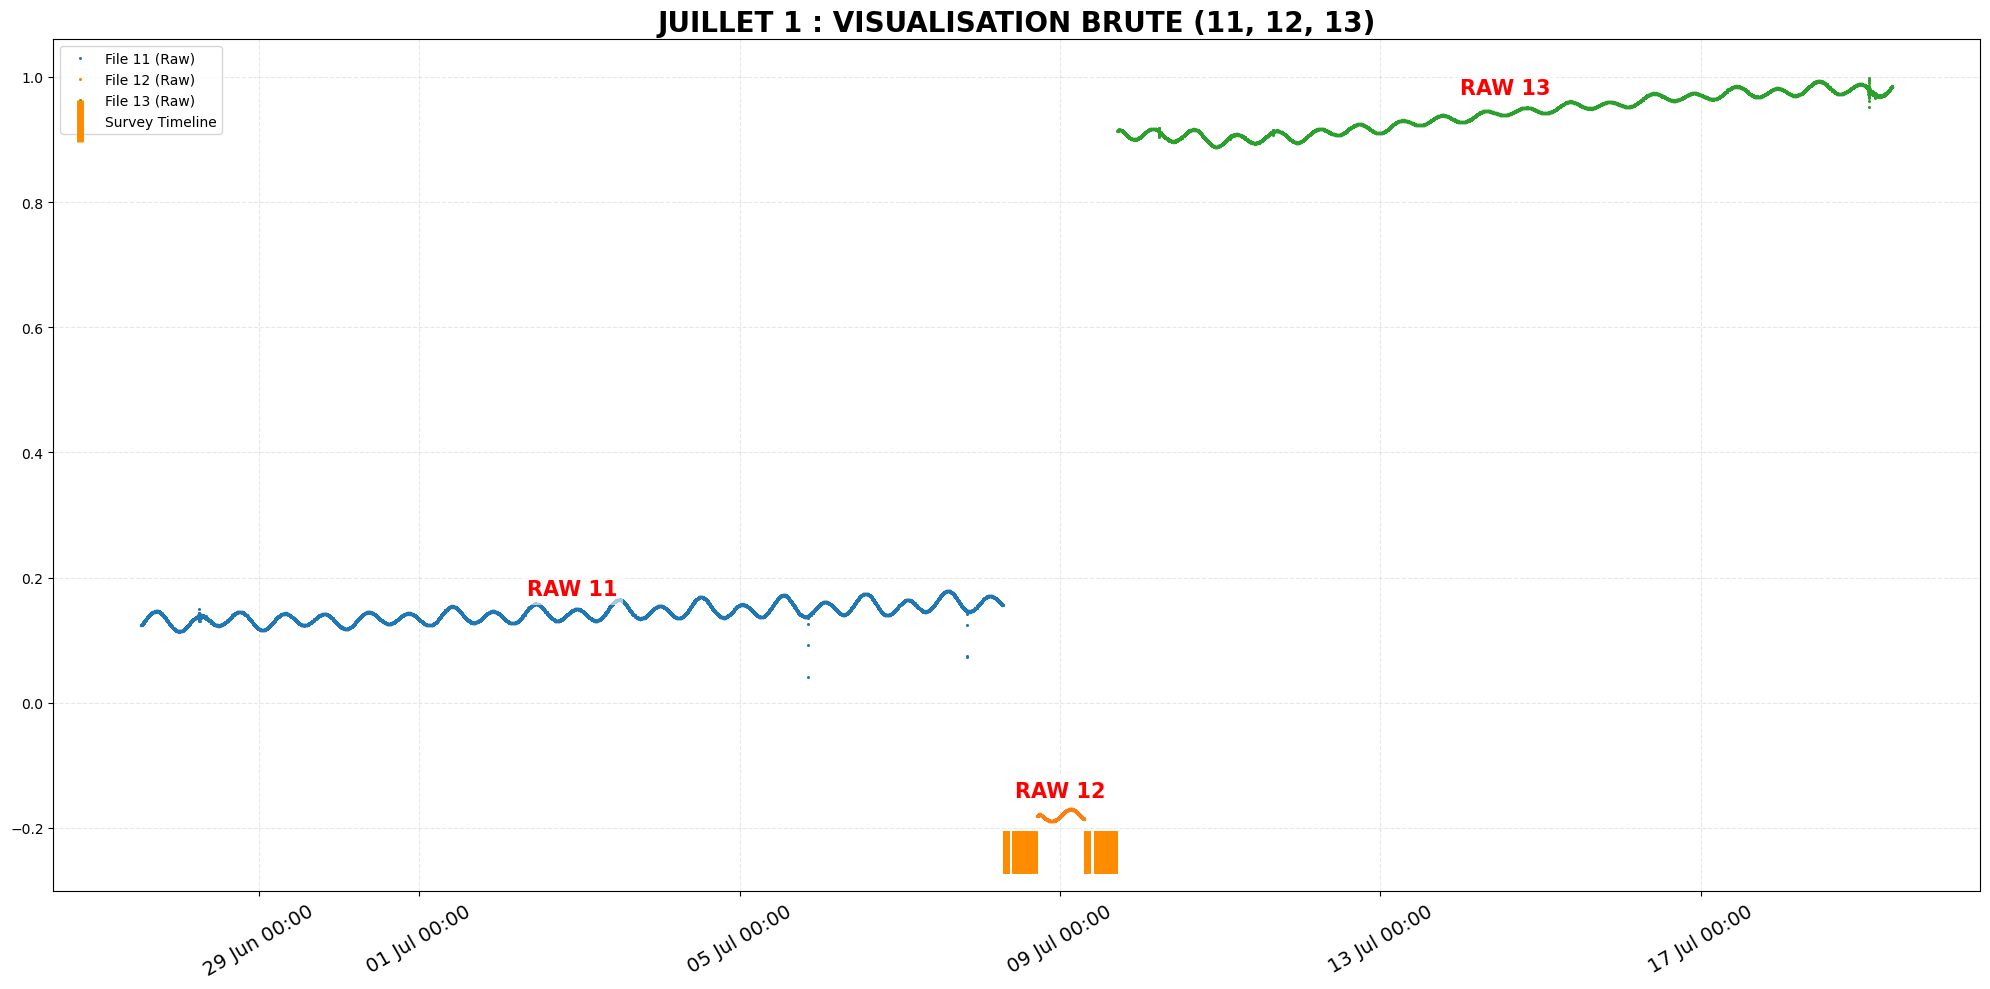

✅ 22 fichiers prêts en mémoire.


In [10]:
# =========================================================
# CELLULE 1 : VISUALISATION RAW - JUILLET 1 (Files 11, 12, 13)
# =========================================================
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. CONFIGURATION DES CHEMINS
path = "Continuous_files_basement/"
all_files = glob.glob(os.path.join(path, "*.csv"))
all_files.sort()

# Dates du bruit instrumental à nettoyer (28 Juin)
debut_err = pd.to_datetime('2024-06-28 06:15:00')
fin_err   = pd.to_datetime('2024-06-28 06:33:00')

# 2. CHARGEMENT DU SURVEY (TERRAIN)
try:
    G_survey = pd.read_csv("Final_Precise_Raw_Gravity_Data.csv", sep=';', decimal=',')
    G_survey.columns = G_survey.columns.str.strip()
    G_survey['datetime'] = pd.to_datetime(G_survey['Date'] + ' ' + G_survey['Time'])
    print("✅ Fichier Survey chargé.")
except Exception as e:
    print(f"⚠️ Erreur Survey : {e}")

# 3. CHARGEMENT DES FICHIERS BASEMENT
data_blocks = {} # On utilise un dictionnaire pour l'accès par index

for i, f in enumerate(all_files):
    try:
        # Tentative avec point-virgule (format Europe)
        df = pd.read_csv(f, sep=';', decimal=',')
        df.columns = df.columns.str.strip()
        
        # Si 'Date' manque, tentative avec virgule (format US)
        if 'Date' not in df.columns:
            df = pd.read_csv(f, sep=',', decimal='.')
            df.columns = df.columns.str.strip()

        # Création du temps et de la gravité corrigée
        df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
        df['G_corr'] = df['ObsG'] - df['Earthtide']
        
        # --- L'ÉTIQUETTE VITALE POUR ÉVITER LES KEYERROR ---
        df['file_index'] = i 
        
        # Nettoyage du bruit spécifique du 28/06
        mask_noise = (df['datetime'] >= debut_err) & (df['datetime'] <= fin_err)
        if mask_noise.any():
            df.loc[mask_noise, 'G_corr'] = np.nan

        # On ignore les 5 premières lignes (stabilisation)
        df = df.iloc[5:].copy()
        data_blocks[i] = df
        
    except Exception as e:
        print(f"⚠️ Erreur sur le fichier {os.path.basename(f)} : {e}")

# 4. PLOT DE JUILLET 1 (Files 11, 12, 13)
indices_july1 = [11, 12, 13] 
plt.figure(figsize=(20, 10))
all_g_values = []

for idx in indices_july1:
    if idx in data_blocks:
        df_raw = data_blocks[idx]
        plt.plot(df_raw['datetime'], df_raw['G_corr'], 'o', markersize=1.2, label=f'File {idx} (Raw)')
        all_g_values.extend(df_raw['G_corr'].dropna().tolist())
        
        # Label ID rouge
        mid_time = df_raw['datetime'].iloc[len(df_raw)//2]
        plt.text(mid_time, df_raw['G_corr'].median() + 0.03, f"RAW {idx}", 
                 color='red', fontsize=15, fontweight='bold', ha='center',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Timeline Survey (Traits orange)
mask_s = (G_survey['datetime'] >= '2024-07-07') & (G_survey['datetime'] <= '2024-07-15')
survey_july = G_survey.loc[mask_s]

if not survey_july.empty and all_g_values:
    y_auto = min(all_g_values) - 0.05
    plt.plot(survey_july['datetime'], [y_auto] * len(survey_july), '|', 
             markersize=30, mew=5, color='darkorange', label='Survey Timeline')

# Mise en forme
plt.title("JUILLET 1 : VISUALISATION BRUTE (11, 12, 13)", fontsize=20, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=30, fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

print(f"✅ {len(data_blocks)} fichiers prêts en mémoire.")

--- LOG D'ALIGNEMENT JUILLET 1 ---
✅ File 12 : Offset cumulé appliqué = 0.342793 mGal
✅ File 13 : Offset cumulé appliqué = -0.756641 mGal


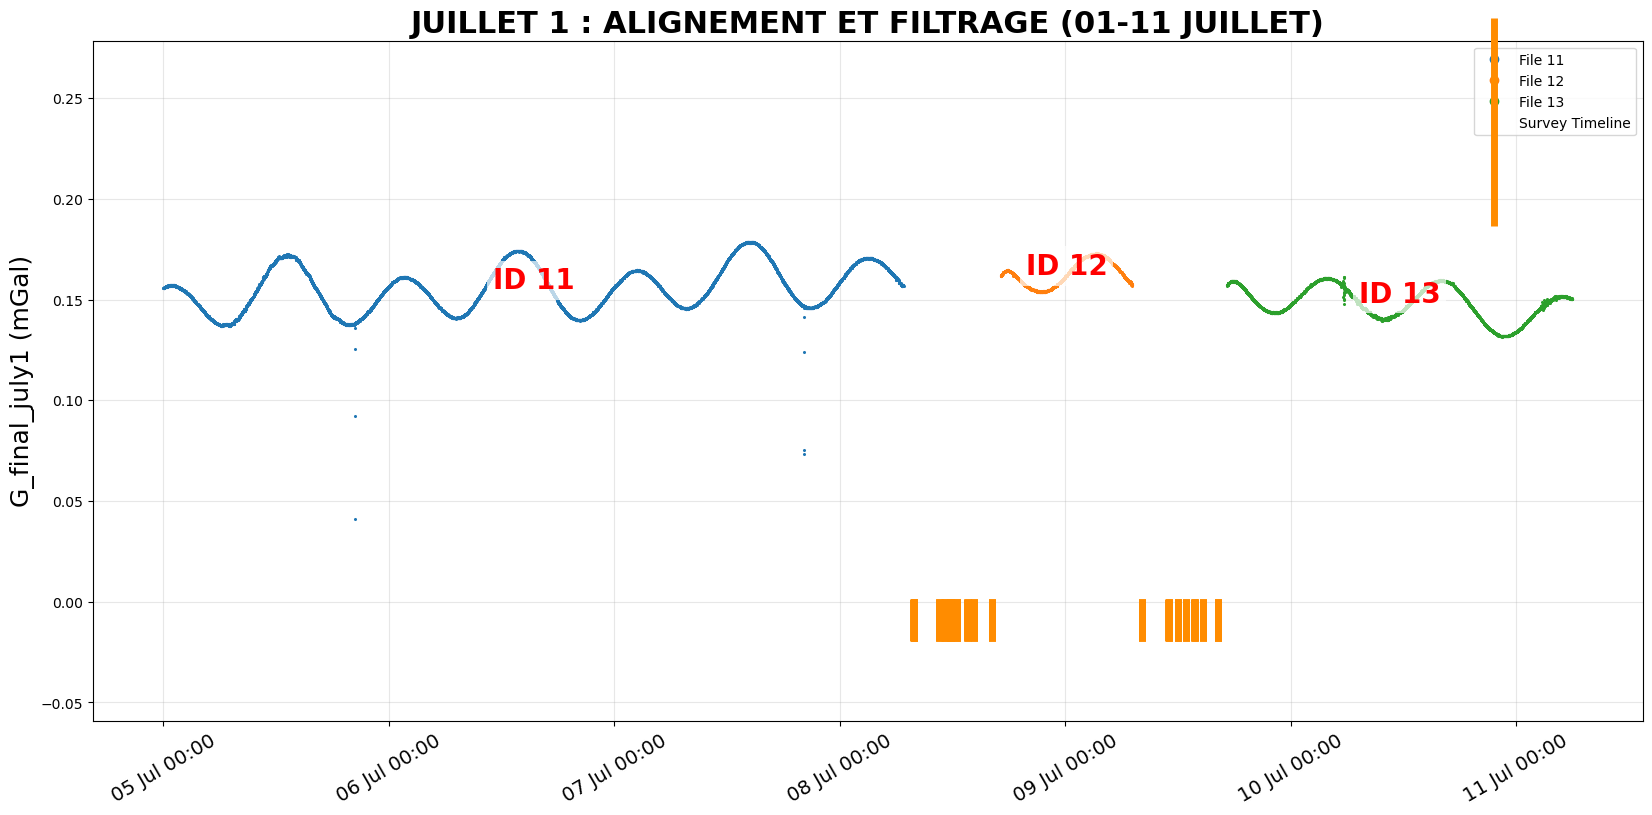

In [11]:
# ==========================================
# CELLULE 2 : ALIGNEMENT JUILLET 1 (Files 11, 12, 13)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# 1. TABLEAU DE BORD DES AJUSTEMENTS MANUELS
# Par défaut à 0.0. Modifie si tu vois un saut anormal.
ajustements_july1 = {11: 0.0, 12: 0.005, 13: 0.0}

# 2. CALCUL DE L'ALIGNEMENT (STITCHING)
indices_july1 = [11, 12, 13]
july1_blocks = []
current_offset = 0

print("--- LOG D'ALIGNEMENT JUILLET 1 ---")
for i, idx in enumerate(indices_july1):
    if idx not in data_blocks:
        print(f"⚠️ Index {idx} non trouvé dans data_blocks.")
        continue
        
    df = data_blocks[idx].copy()
    
    # --- FILTRAGE DES DATES (01/07 au 11/07) ---
    mask_dates = (df['datetime'] >= '2024-07-05') & (df['datetime'] <= '2024-07-11 05:59:59')
    df = df[mask_dates].copy()
    
    if df.empty:
        print(f"⚠️ Le fichier {idx} est vide sur la période 01-11 Juillet. Sauté.")
        continue

    # Injection de l'index pour le plot
    df['file_index'] = idx 

    # --- LOGIQUE D'ALIGNEMENT ---
    if i > 0 and len(july1_blocks) > 0:
        # Médiane sur la jonction (20 points)
        val_end_prev = july1_blocks[-1]['G_corr'].tail(20).median()
        val_start_curr = df['G_corr'].head(20).median()
        
        # Calcul du saut
        step_offset = val_end_prev - val_start_curr
        current_offset += (step_offset + ajustements_july1[idx])
        print(f"✅ File {idx} : Offset cumulé appliqué = {current_offset:.6f} mGal")
    
    # Création de la colonne finale alignée
    df['G_final_july1'] = df['G_corr'] + current_offset
    july1_blocks.append(df)

# Fusion finale du bloc Juillet 1
df_july1_total = pd.concat(july1_blocks, ignore_index=True)

# ---------------------------------------------------------
# 3. PLOT DE VÉRIFICATION (AUTO-FOCUS)
# ---------------------------------------------------------
plt.figure(figsize=(20, 10))
y_min = df_july1_total['G_final_july1'].min()
y_max = df_july1_total['G_final_july1'].max()

for idx in indices_july1:
    block = df_july1_total[df_july1_total['file_index'] == idx]
    if not block.empty:
        plt.plot(block['datetime'], block['G_final_july1'], 'o', markersize=1.2, label=f'File {idx}')
        
        # Label ID
        mid_time = block['datetime'].iloc[len(block)//2]
        plt.text(mid_time, block['G_final_july1'].median(), f"ID {idx}", 
                 color='red', fontsize=20, fontweight='bold', ha='center',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Timeline Survey (Orange)
mask_s = (G_survey['datetime'] >= df_july1_total['datetime'].min()) & \
         (G_survey['datetime'] <= df_july1_total['datetime'].max())
survey_july1 = G_survey.loc[mask_s]

if not survey_july1.empty:
    # Calage auto sous les données
    plt.plot(survey_july1['datetime'], [y_min - 0.05] * len(survey_july1), '|', 
             markersize=30, mew=5, color='darkorange', label='Survey Timeline')

# Mise en forme
plt.title("JUILLET 1 : ALIGNEMENT ET FILTRAGE (01-11 JUILLET)", fontsize=22, fontweight='bold')
plt.ylabel("G_final_july1 (mGal)", fontsize=18)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=30, fontsize=14)

# Ajustement de l'axe Y pour tout voir (fichiers + survey)
plt.ylim(y_min - 0.1, y_max + 0.1)

plt.subplots_adjust(bottom=0.2)
plt.legend(loc='upper right', markerscale=5)
plt.show()

--- RÉSULTATS JUILLET 1 (Files [11, 12, 13]) ---
Précision (RMSE) : 0.009667 mGal
Coefficient R² : 0.210384
Dérive moyenne sur la période : -0.00059 mGal/jour
Formule : G(t) = (-2.174981e-13)*t² + (1.106608e-07)*t + 0.146131


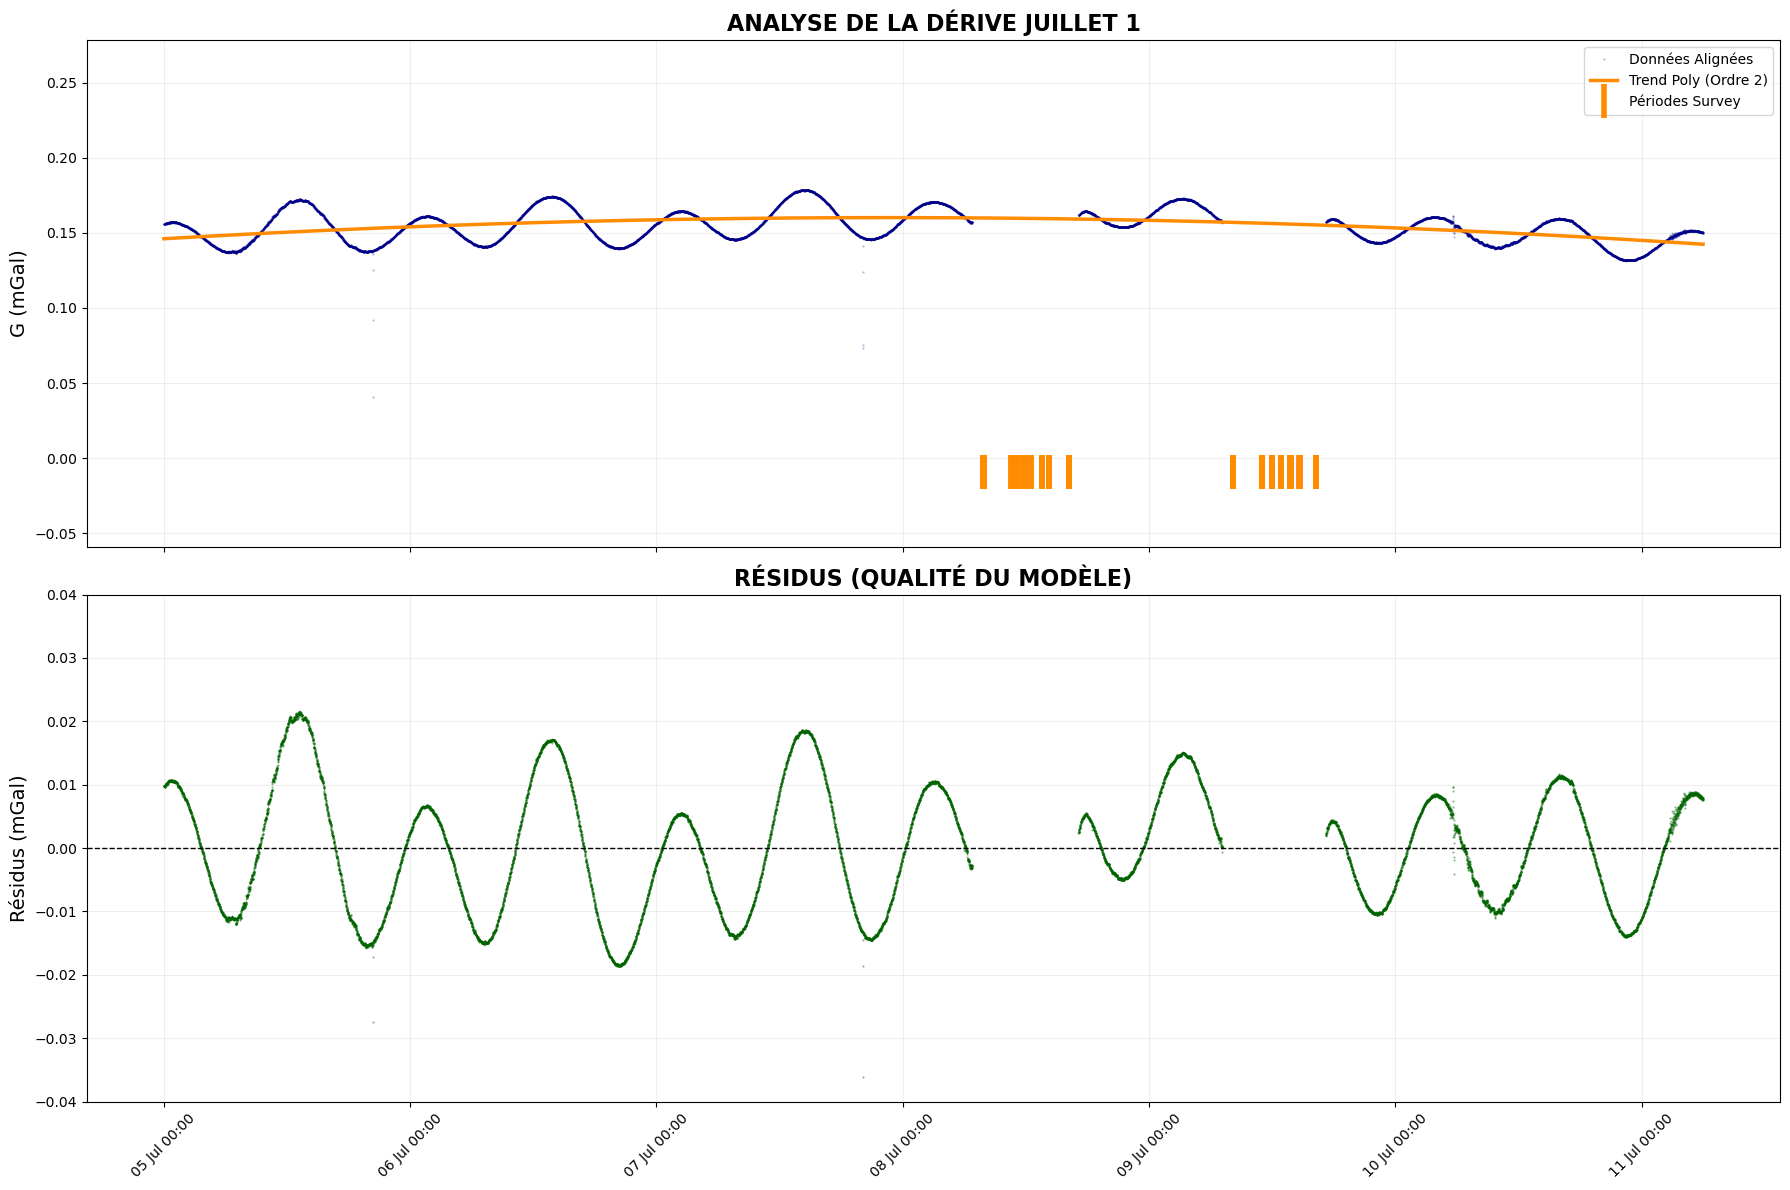

In [12]:
# ==========================================
# CELLULE 3 : FIT POLYNOMIAL (2nd DEGRÉ) - JUILLET 1
# ==========================================
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# 1. PRÉPARATION DES DONNÉES
df_july1_filtre = df_july1_total.copy()
t_start = df_july1_filtre['datetime'].min()
df_july1_filtre['t_seconds'] = (df_july1_filtre['datetime'] - t_start).dt.total_seconds()

X = df_july1_filtre['t_seconds'].values
y = df_july1_filtre['G_final_july1'].values

# 2. CALCUL DU MODÈLE POLYNOMIAL (ORDRE 2)
coeffs = np.polyfit(X, y, 2)
p = np.poly1d(coeffs)
y_trend_poly2 = p(X)

# 3. INDICATEURS DE PERFORMANCE
r2_july1 = r2_score(y, y_trend_poly2)
rmse_july1 = np.sqrt(mean_squared_error(y, y_trend_poly2))
# Calcul de la dérive moyenne en mGal/jour
pente_july1 = (p(X[-1]) - p(X[0])) / ((X[-1] - X[0]) / 86400)

# 4. APPLICATION DE LA CORRECTION (RÉSIDUS)
df_july1_filtre['G_no_drift_poly2'] = y - y_trend_poly2

# 5. AFFICHAGE DES RÉSULTATS DANS LA CONSOLE
print(f"--- RÉSULTATS JUILLET 1 (Files {indices_july1}) ---")
print(f"Précision (RMSE) : {rmse_july1:.6f} mGal")
print(f"Coefficient R² : {r2_july1:.6f}")
print(f"Dérive moyenne sur la période : {pente_july1:.5f} mGal/jour")
print(f"Formule : G(t) = ({coeffs[0]:.6e})*t² + ({coeffs[1]:.6e})*t + {coeffs[2]:.6f}")

# 6. STOCKAGE COMPLET POUR LE RÉCAPITULATIF FINAL
modeles_derive = {} if 'modeles_derive' not in locals() else modeles_derive
modeles_derive['july1'] = {
    'coeffs': coeffs,
    't_start': t_start,
    'rmse': rmse_july1,
    'r2': r2_july1,
    'drift': pente_july1
}

# 7. PLOT DE VÉRIFICATION
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# --- Graphique 1 : Données + Trend ---
ax1.plot(df_july1_filtre['datetime'], y, 'o', markersize=0.5, color='darkblue', alpha=0.3, label='Données Alignées')
# Trait de dérive continu
t_trace = np.linspace(X.min(), X.max(), 1000)
dates_trace = [t_start + pd.Timedelta(seconds=s) for s in t_trace]
ax1.plot(dates_trace, p(t_trace), color='darkorange', linewidth=2.5, label='Trend Poly (Ordre 2)')

# Survey Timeline
mask_s = (G_survey['datetime'] >= df_july1_filtre['datetime'].min()) & \
         (G_survey['datetime'] <= df_july1_filtre['datetime'].max())
survey_july1 = G_survey.loc[mask_s]
if not survey_july1.empty:
    y_min_plot = y.min() - 0.05
    ax1.plot(survey_july1['datetime'], [y_min_plot] * len(survey_july1), '|', 
             markersize=25, mew=4, color='darkorange', label='Périodes Survey')

ax1.set_title("ANALYSE DE LA DÉRIVE JUILLET 1", fontsize=16, fontweight='bold')
ax1.set_ylabel("G (mGal)", fontsize=14)
ax1.grid(True, alpha=0.2)
ax1.set_ylim(y.min() - 0.1, y.max() + 0.1)
ax1.legend(loc='upper right')

# --- Graphique 2 : Résidus ---
ax2.plot(df_july1_filtre['datetime'], df_july1_filtre['G_no_drift_poly2'], 'o', markersize=0.5, color='darkgreen', alpha=0.5)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title("RÉSIDUS (QUALITÉ DU MODÈLE)", fontsize=16, fontweight='bold')
ax2.set_ylim(-0.04, 0.04)
ax2.set_ylabel("Résidus (mGal)", fontsize=14)
ax2.grid(True, alpha=0.2)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## SURVEY 5 - 31 JULY

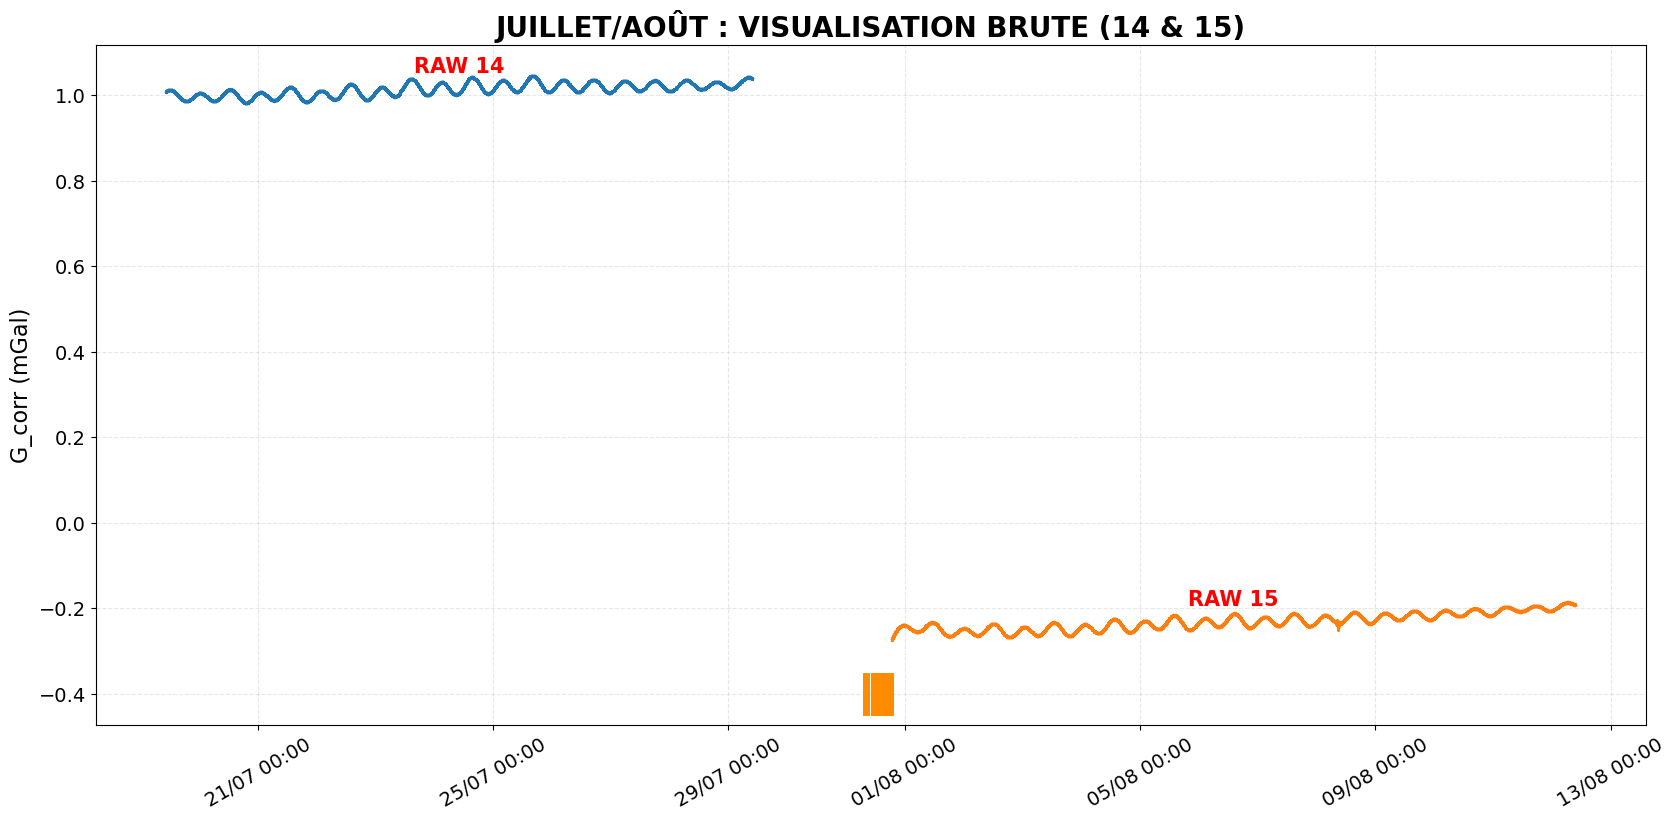

ℹ️ Le saut naturel entre le File 14 et le File 15 est de : -1.311632 mGal


In [13]:
# ==========================================
# CELLULE 1 : VISUALISATION RAW - 14 & 15 CUT
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

indices_final = [14, 15]
plt.figure(figsize=(20, 10))

for idx in indices_final:
    df_raw = data_blocks[idx].copy()
    plt.plot(df_raw['datetime'], df_raw['G_corr'], 'o', markersize=1.2, label=f'File {idx} (Raw)')
    
    mid_time = df_raw['datetime'].iloc[len(df_raw)//2]
    plt.text(mid_time, df_raw['G_corr'].median() + 0.04, f"RAW {idx}", 
             color='red', fontsize=15, fontweight='bold', ha='center')

# Timeline Survey
mask_s = (G_survey['datetime'] >= data_blocks[14]['datetime'].min()) & \
         (G_survey['datetime'] <= data_blocks[15]['datetime'].max())
survey_pts = G_survey.loc[mask_s]

if not survey_pts.empty:
    plt.plot(survey_pts['datetime'], [-0.4] * len(survey_pts), '|', 
             markersize=30, mew=5, color='darkorange', label='Survey Timeline')

plt.title("JUILLET/AOÛT : VISUALISATION BRUTE (14 & 15)", fontsize=20, fontweight='bold')
plt.ylabel("G_corr (mGal)", fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
plt.xticks(rotation=30, fontsize=14)
plt.yticks(fontsize=14)
plt.subplots_adjust(bottom=0.2)
plt.show()

gap = data_blocks[15]['G_corr'].head(10).median() - data_blocks[14]['G_corr'].tail(10).median()
print(f"ℹ️ Le saut naturel entre le File 14 et le File 15 est de : {gap:.6f} mGal")

--- LOG D'ALIGNEMENT JUILLET/AOÛT ---
✅ Offset cumulé au File 15 : 1.298076 mGal


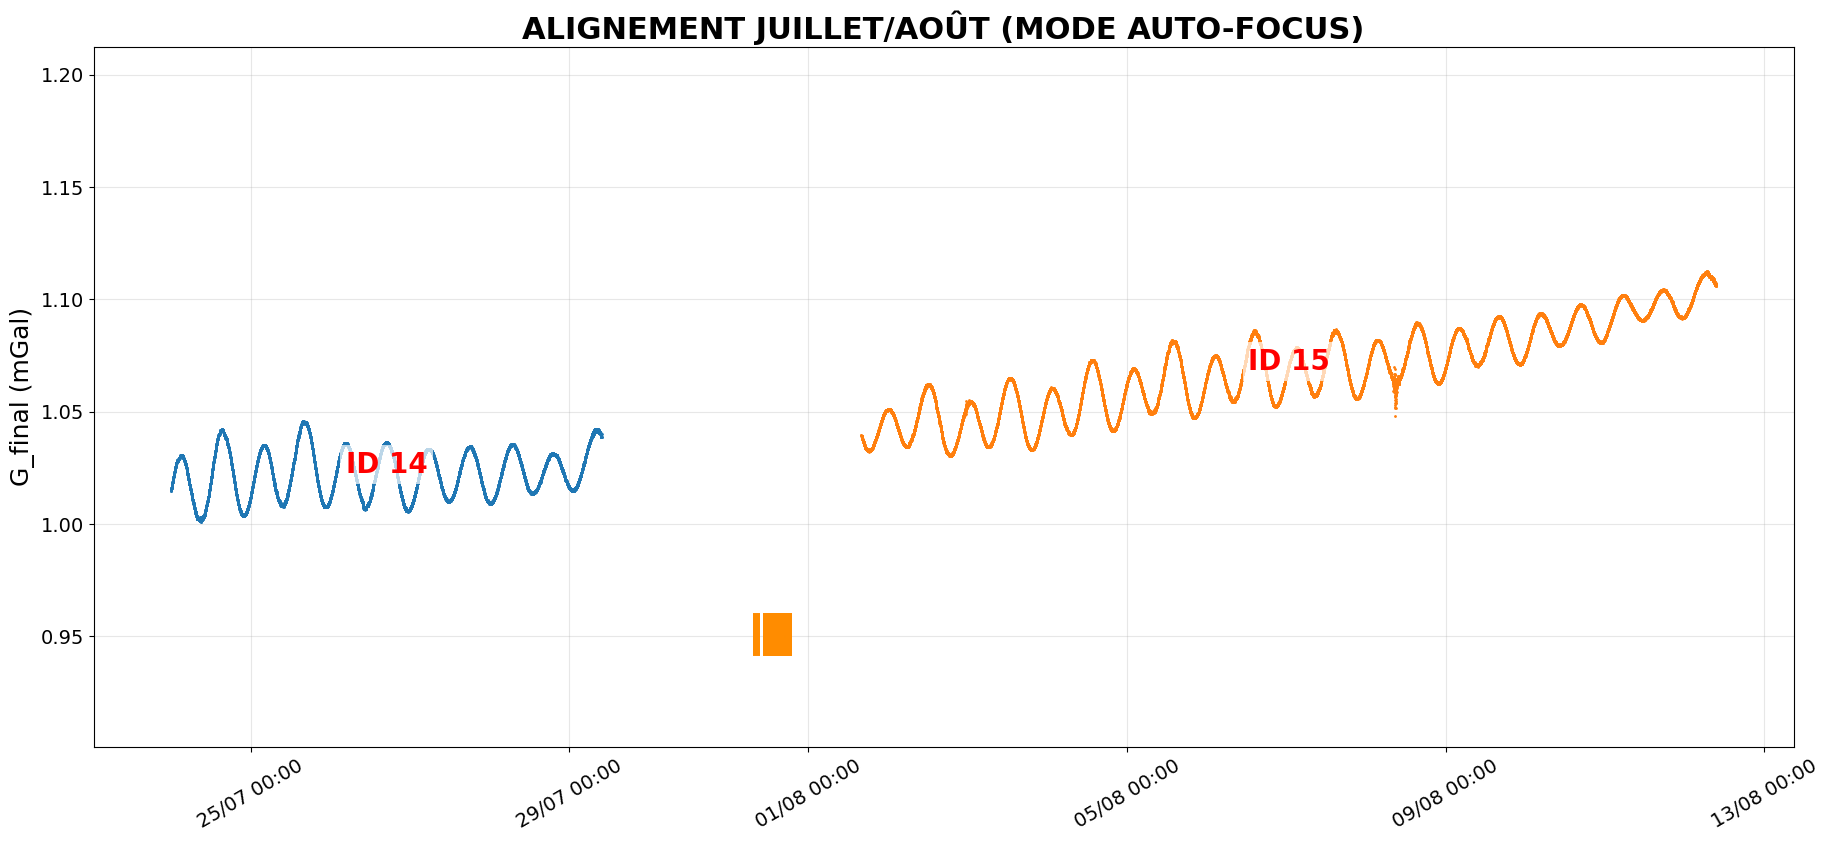

In [14]:
# ==========================================
# CELLULE 2 : ALIGNEMENT JUILLET/AOÛT (AUTO-FOCUS)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# 1. TON TABLEAU DE BORD
ajustements_final = {14: 0.0, 15: 0.0}

# 2. CALCUL DE L'ALIGNEMENT
indices_final = [14, 15]
blocks_final = []
current_offset = 0

print("--- LOG D'ALIGNEMENT JUILLET/AOÛT ---")
for i, idx in enumerate(indices_final):
    df = data_blocks[idx].copy()
    
    # FIX SÉCURITÉ : file_index
    df['file_index'] = idx 
    
    # FILTRAGE (CUTS)
    if idx == 14:
        df = df[df['datetime'] >= '2024-07-24 00:00:00'].copy()
    if idx == 15:
        df = df[df['datetime'] >= '2024-08-01 16:00:00'].copy()
    
    # CALCUL DE LA MARCHE
    if i > 0 and not df.empty:
        val_end_prev = blocks_final[i-1]['G_corr'].tail(20).median()
        val_start_curr = df['G_corr'].head(20).median()
        step_offset = val_end_prev - val_start_curr
        current_offset += (step_offset + ajustements_final[idx])
        print(f"✅ Offset cumulé au File {idx} : {current_offset:.6f} mGal")
        
    df['G_final_ja'] = df['G_corr'] + current_offset
    blocks_final.append(df)

df_ja_total = pd.concat(blocks_final, ignore_index=True)

# ---------------------------------------------------------
# 3. PLOT DE VÉRIFICATION (VERSION AUTO)
# ---------------------------------------------------------
plt.figure(figsize=(20, 10))

# On récupère les min/max pour caler le survey proprement
y_min_data = df_ja_total['G_final_ja'].min()
y_max_data = df_ja_total['G_final_ja'].max()

# --- BASEMENT ---
for idx in indices_final:
    block = df_ja_total[df_ja_total['file_index'] == idx]
    if not block.empty:
        plt.plot(block['datetime'], block['G_final_ja'], 'o', markersize=1, label=f'File {idx}')
        
        # Label ID placé pile sur la médiane du bloc
        mid_time = block['datetime'].iloc[len(block)//2]
        plt.text(mid_time, block['G_final_ja'].median(), f"ID {idx}", 
                 color='red', fontsize=20, fontweight='bold', ha='center',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# --- TIMELINE SURVEY (Orange) ---
mask_s = (G_survey['datetime'] >= df_ja_total['datetime'].min()) & \
         (G_survey['datetime'] <= df_ja_total['datetime'].max())
survey_pts = G_survey.loc[mask_s]

if not survey_pts.empty:
    # On place le survey 0.05 mGal SOUS la donnée la plus basse
    y_survey = y_min_data - 0.05
    plt.plot(survey_pts['datetime'], [y_survey] * len(survey_pts), '|', 
             markersize=30, mew=5, color='darkorange', label='Survey Timeline')

# --- CONFIGURATION (AUTO-SCALE) ---
plt.title("ALIGNEMENT JUILLET/AOÛT (MODE AUTO-FOCUS)", fontsize=22, fontweight='bold')
plt.ylabel("G_final (mGal)", fontsize=18)
plt.grid(True, alpha=0.3)

# On laisse Matplotlib gérer l'axe Y, mais on rajoute une petite marge en haut et en bas
plt.ylim(y_min_data - 0.1, y_max_data + 0.1)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
plt.xticks(rotation=30, fontsize=14)
plt.yticks(fontsize=14)

plt.subplots_adjust(bottom=0.2, top=0.9, left=0.1, right=0.95)
plt.show()

--- RÉSULTATS JUILLET/AOÛT (14 & 15 CLEAN) ---
RMSE : 0.009704 mGal | R² : 0.877448
Formule : G(t) = (2.241874e-14)*t² + (1.257905e-08)*t + 1.018647
Dérive moyenne : 0.00433 mGal/jour


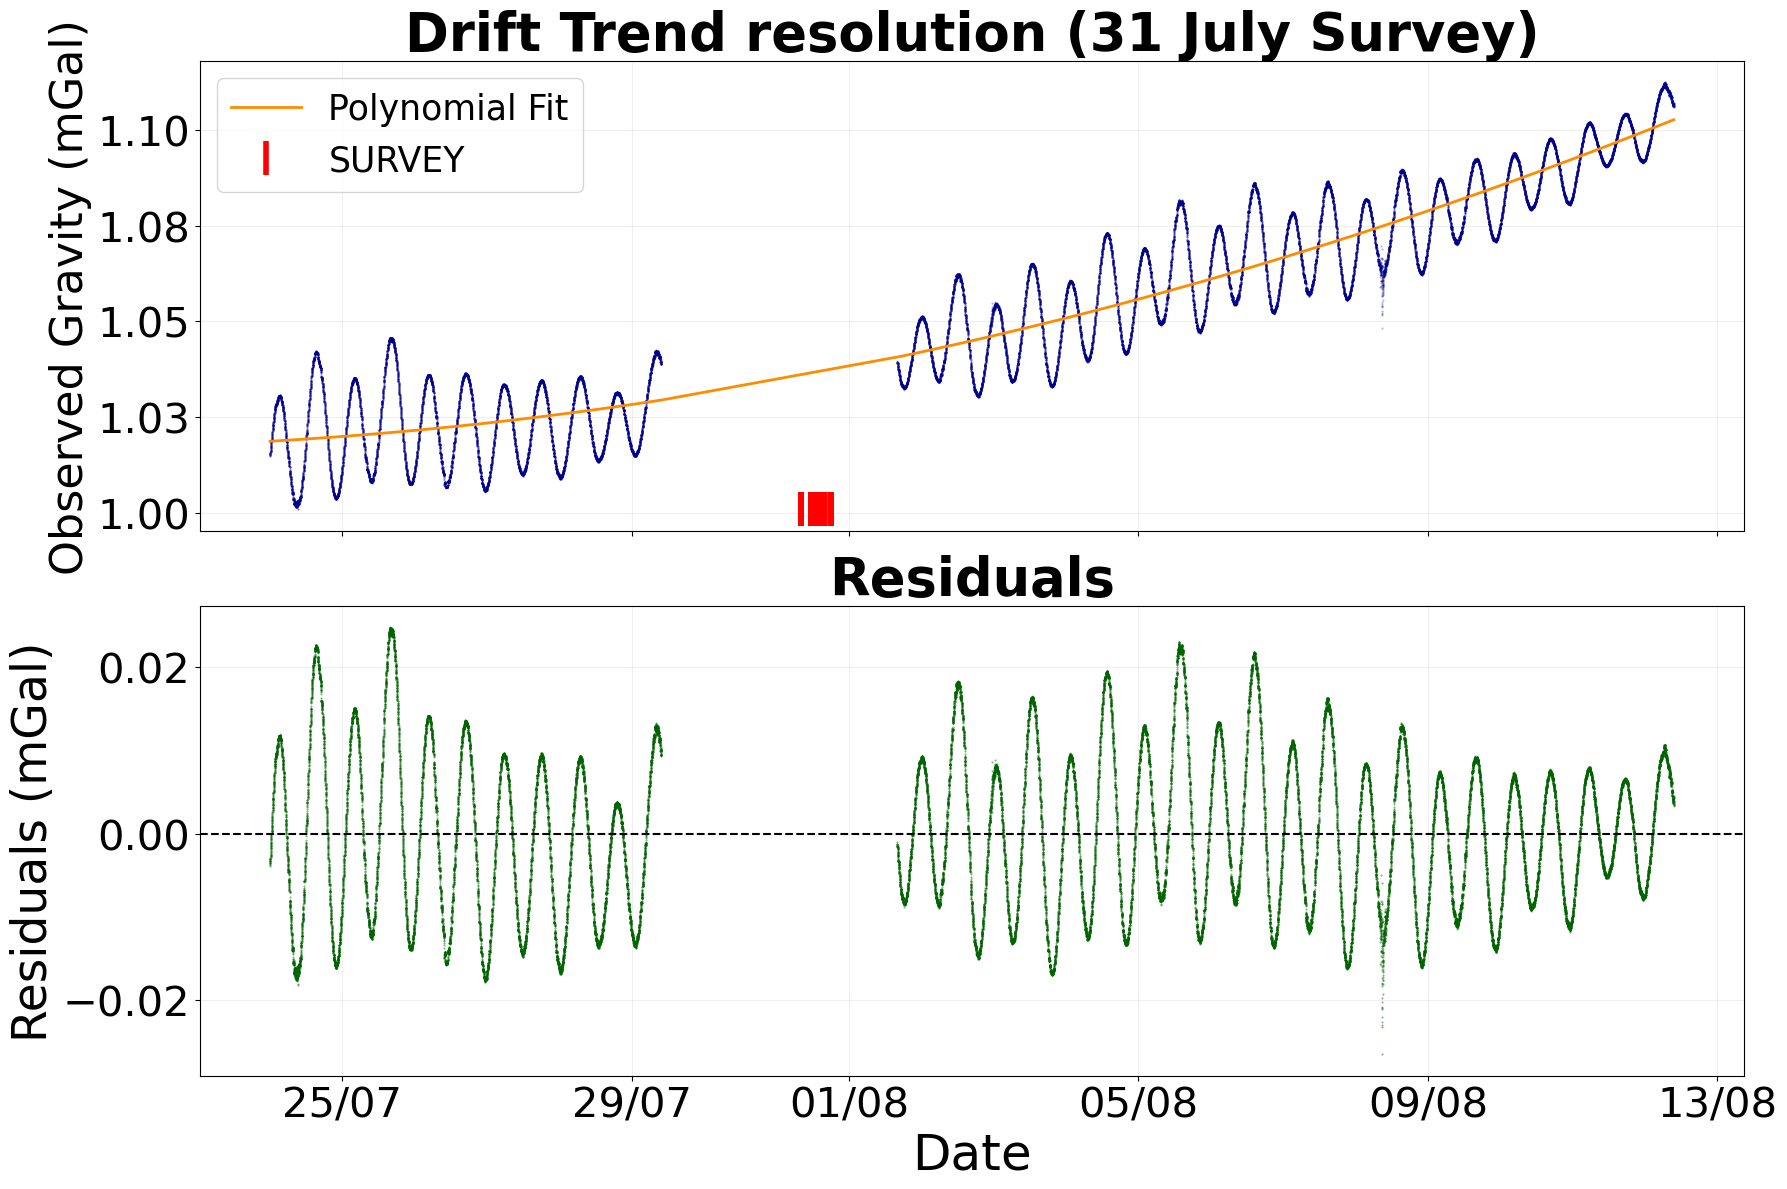

In [15]:
# ==========================================
# CELLULE 3 : FIT POLYNOMIAL (2nd DEGRÉ) - JA
# ==========================================
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.ticker as mticker # À rajouter en haut de ton script

df_fit = df_ja_total.copy()
t_start = df_fit['datetime'].min()
df_fit['t_seconds'] = (df_fit['datetime'] - t_start).dt.total_seconds()

X = df_fit['t_seconds'].values
y = df_fit['G_final_ja'].values

coeffs = np.polyfit(X, y, 2)
p = np.poly1d(coeffs)
y_trend = p(X)

rmse_val = np.sqrt(mean_squared_error(y, y_trend))
df_fit['G_no_drift'] = y - y_trend

print(f"--- RÉSULTATS JUILLET/AOÛT (14 & 15 CLEAN) ---")
print(f"RMSE : {rmse_val:.6f} mGal | R² : {r2_score(y, y_trend):.6f}")
print(f"Formule : G(t) = ({coeffs[0]:.6e})*t² + ({coeffs[1]:.6e})*t + {coeffs[2]:.6f}")
pente_moyenne = (p(X[-1]) - p(X[0])) / ((X[-1] - X[0]) / 86400)
print(f"Dérive moyenne : {pente_moyenne:.5f} mGal/jour")

# 7.Save stats
# Initialisation du dictionnaire si besoin
modeles_derive = {} if 'modeles_derive' not in locals() else modeles_derive
# Stockage avec TOUS les indicateurs pour le tableau récapitulatif
modeles_derive['july2'] = {
    'coeffs': coeffs,        # Le vecteur [a, b, c]
    't_start': t_start,      # La date de référence
    'rmse': rmse_val,        # Ta variable de précision
    'r2': r2_score(y, y_trend),          # Ton coefficient R²
    'drift': pente_moyenne # Ta dérive en mGal/jour
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# Graph 1 : Trend
ax1.plot(df_fit['datetime'], y, 'o', markersize=0.5, color='darkblue', alpha=0.3)
ax1.plot(df_fit['datetime'], y_trend, color='darkorange', linewidth=2, label='Polynomial Fit')
survey_ja = G_survey[(G_survey['datetime'] >= df_fit['datetime'].min()) & (G_survey['datetime'] <= df_fit['datetime'].max())]
if not survey_ja.empty:
    ax1.plot(survey_ja['datetime'], [y.min()] * len(survey_ja), '|', markersize=25, mew=4, color='red', label='SURVEY')

ax1.set_title("Drift Trend resolution (31 July Survey)", fontsize=38, fontweight='bold')
ax1.set_ylabel("Observed Gravity (mGal)", fontsize=32)
ax1.grid(True, alpha=0.2)
ax1.tick_params(axis='y', labelsize=30)
ax1.legend(fontsize=25)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# Graph 2 : Résidus
ax2.plot(df_fit['datetime'], df_fit['G_no_drift'], 'o', markersize=0.5, color='darkgreen', alpha=0.5)
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title("Residuals", fontsize=38, fontweight='bold')
ax2.set_ylabel("Residuals (mGal)", fontsize=34)
ax2.grid(True, alpha=0.2)
ax2.set_xlabel("Date", fontsize=36)
ax2.tick_params(axis='y', labelsize=30)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
plt.xticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.savefig('drift_analysis_31July.png', bbox_inches='tight')
plt.show()

## SURVEY 6 - OCT (7-14)

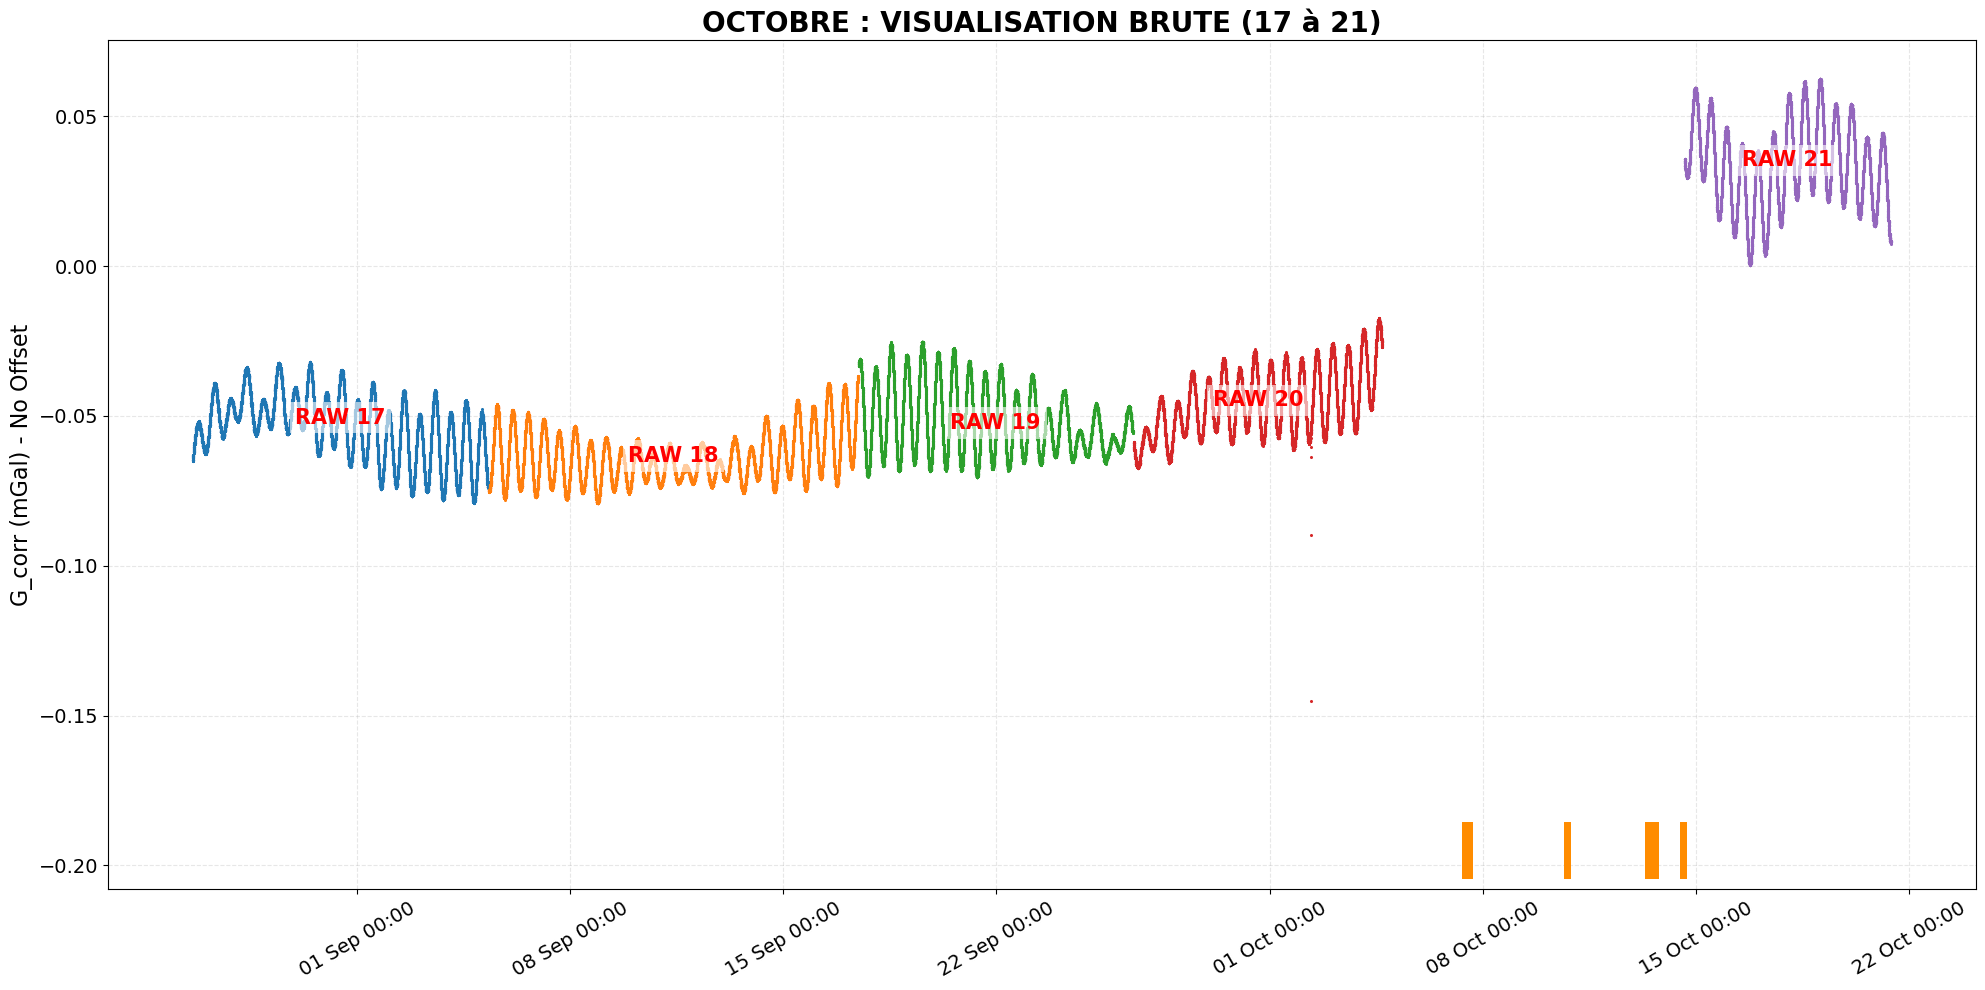


--- Analyse des sauts (Median Gap) ---
ℹ️ Saut 17 -> 18 : -0.001037 mGal
ℹ️ Saut 18 -> 19 : 0.003597 mGal
ℹ️ Saut 19 -> 20 : -0.003521 mGal
ℹ️ Saut 20 -> 21 : 0.062527 mGal


In [16]:
# ==========================================
# CELLULE 1 : VISUALISATION RAW - OCTOBRE (17 à 21)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

indices_octobre = [17, 18, 19, 20, 21]
plt.figure(figsize=(20, 10))

all_g_oct = []

# 1. TRACÉ DES DONNÉES BASEMENT
for idx in indices_octobre:
    # Correction de l'erreur : on vérifie l'existence de façon plus propre
    try:
        df_raw = data_blocks[idx].copy()
        
        plt.plot(df_raw['datetime'], df_raw['G_corr'], 'o', markersize=1.2, label=f'File {idx} (Raw)')
        
        # On stocke les valeurs pour l'échelle auto
        all_g_oct.extend(df_raw['G_corr'].dropna().tolist())
        
        # Repère visuel pour l'ID
        mid_time = df_raw['datetime'].iloc[len(df_raw)//2]
        plt.text(mid_time, df_raw['G_corr'].median(), f"RAW {idx}", 
                 color='red', fontsize=15, fontweight='bold', ha='center',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
                 
    except (KeyError, IndexError):
        print(f"⚠️ Le fichier {idx} n'est pas disponible dans data_blocks.")
        continue

# 2. TIMELINE SURVEY (Orange)
mask_s = (G_survey['datetime'] >= '2024-10-07') & (G_survey['datetime'] <= '2024-10-15')
survey_oct = G_survey.loc[mask_s]

if not survey_oct.empty and all_g_oct:
    # POSITION AUTO : On place la barre orange 0.05 mGal sous le minimum d'octobre
    y_min_oct = min(all_g_oct)
    plt.plot(survey_oct['datetime'], [y_min_oct - 0.05] * len(survey_oct), '|', 
             markersize=40, mew=5, color='darkorange', label='Survey Timeline')

# 3. MISE EN FORME
plt.title("OCTOBRE : VISUALISATION BRUTE (17 à 21)", fontsize=20, fontweight='bold')
plt.ylabel("G_corr (mGal) - No Offset", fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--')

# Formatage des dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=30, fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

# 4. CALCUL DES SAUTS (INFO CONSOLE)
print("\n--- Analyse des sauts (Median Gap) ---")
for i in range(len(indices_octobre)-1):
    i_curr, i_next = indices_octobre[i], indices_octobre[i+1]
    try:
        gap = data_blocks[i_next]['G_corr'].head(10).median() - data_blocks[i_curr]['G_corr'].tail(10).median()
        print(f"ℹ️ Saut {i_curr} -> {i_next} : {gap:.6f} mGal")
    except:
        pass

--- LOG D'ALIGNEMENT OCTOBRE ---
✅ Offset appliqué au File 19 : -0.003934 mGal
✅ Offset appliqué au File 20 : -0.000033 mGal
✅ Offset appliqué au File 21 : -0.062250 mGal


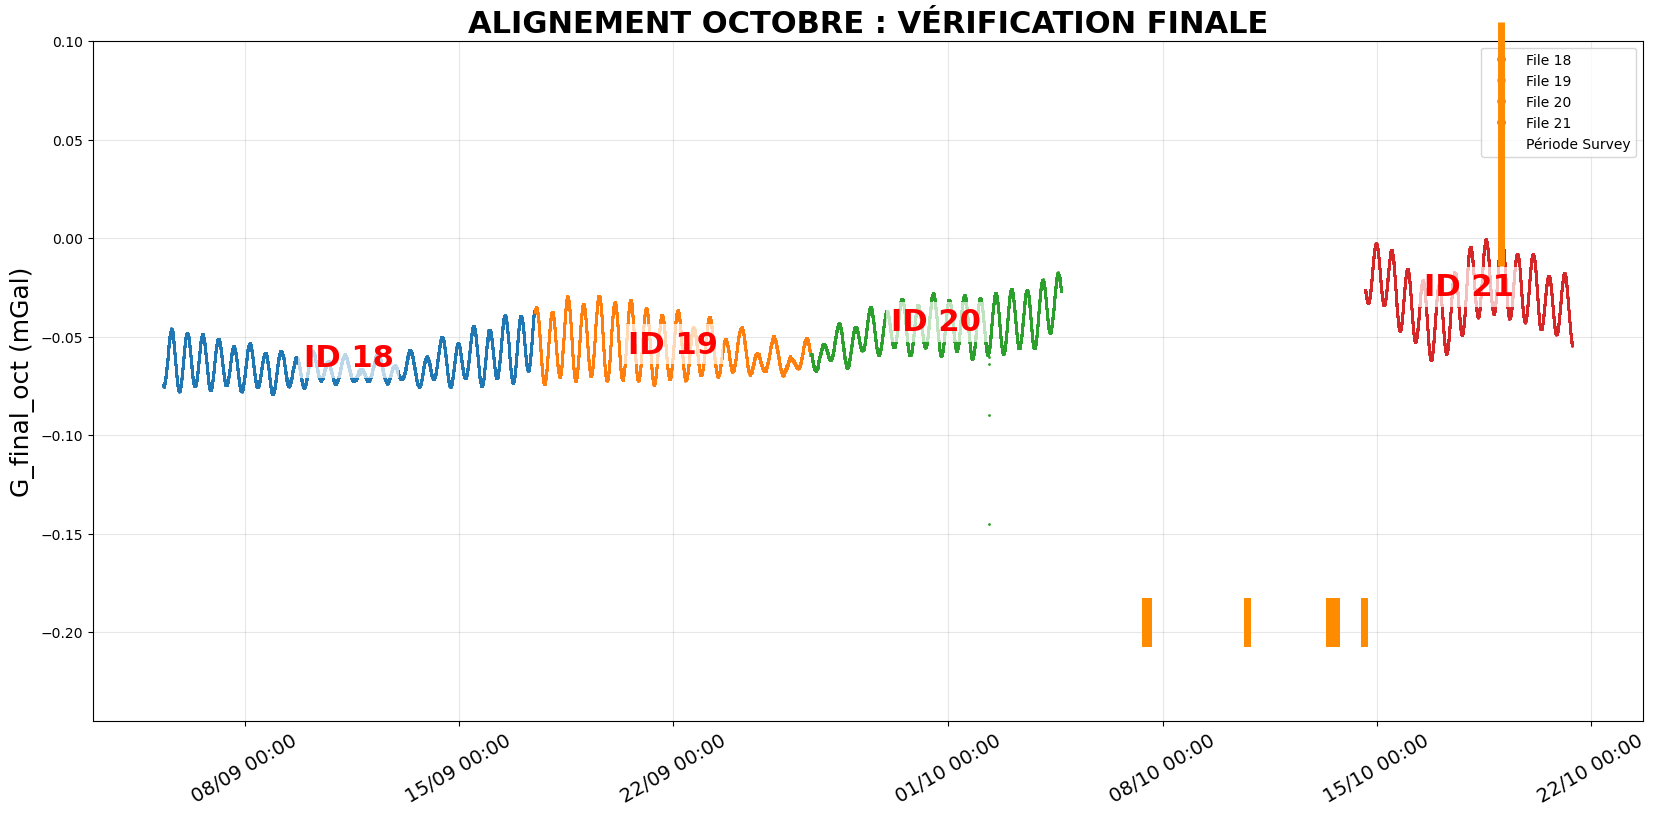

In [17]:
# ==========================================
# CELLULE 2 : ALIGNEMENT OCTOBRE (FIXED & ROBUSTE)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# 1. TON TABLEAU DE BORD
ajustements_oct = {18: 0.0, 19: 0.0, 20: 0.0, 21: 0.0}

# 2. CALCUL DE L'ALIGNEMENT
indices_oct = [18, 19, 20, 21]
oct_blocks = []
current_offset = 0

print("--- LOG D'ALIGNEMENT OCTOBRE ---")
for i, idx in enumerate(indices_oct):
    # --- FIX SÉCURITÉ : On évite le ValueError en vérifiant l'index proprement ---
    try:
        # On essaie de récupérer le bloc
        df = data_blocks[idx].copy()
    except:
        print(f"⚠️ Index {idx} non trouvé. On passe au suivant.")
        continue
    
    # --- FIX KEYERROR : On injecte l'index de fichier ici ---
    df['file_index'] = idx 
    
    # --- CALCUL DE LA MARCHE ---
    if i > 0 and len(oct_blocks) > 0:
        # Médiane sur les 20 derniers points du bloc précédent
        val_end_prev = oct_blocks[-1]['G_corr'].tail(20).median()
        # Médiane sur les 20 premiers points du bloc actuel
        val_start_curr = df['G_corr'].head(20).median()
        
        step_offset = val_end_prev - val_start_curr
        current_offset += (step_offset + ajustements_oct[idx])
        print(f"✅ Offset appliqué au File {idx} : {current_offset:.6f} mGal")
        
    df['G_final_oct'] = df['G_corr'] + current_offset
    oct_blocks.append(df)

# Fusion finale
df_oct_total = pd.concat(oct_blocks, ignore_index=True)

# ---------------------------------------------------------
# 3. PLOT DE VÉRIFICATION
# ---------------------------------------------------------
plt.figure(figsize=(20, 10))

# --- BASEMENT ---
for idx in indices_oct:
    # On filtre les données par index
    block = df_oct_total[df_oct_total['file_index'] == idx]
    if not block.empty:
        plt.plot(block['datetime'], block['G_final_oct'], 'o', markersize=1, label=f'File {idx}')
        
        # Repères ID
        mid_time = block['datetime'].iloc[len(block)//2]
        plt.text(mid_time, block['G_final_oct'].median(), f"ID {idx}", 
                 color='red', fontsize=22, fontweight='bold', ha='center',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# --- TIMELINE SURVEY (Orange) ---
mask_s = (G_survey['datetime'] >= df_oct_total['datetime'].min()) & \
         (G_survey['datetime'] <= df_oct_total['datetime'].max())
survey_oct = G_survey.loc[mask_s]

if not survey_oct.empty:
    # Calage dynamique en bas du graphique
    y_min_oct = df_oct_total['G_final_oct'].min()
    plt.plot(survey_oct['datetime'], [y_min_oct - 0.05] * len(survey_oct), '|', 
             markersize=35, mew=5, color='darkorange', label='Période Survey')

# --- MISE EN FORME ---
plt.title("ALIGNEMENT OCTOBRE : VÉRIFICATION FINALE", fontsize=22, fontweight='bold')
plt.ylabel("G_final_oct (mGal)", fontsize=18)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
plt.xticks(rotation=30, fontsize=14)

# On ajuste l'axe Y automatiquement avec une marge
plt.ylim(df_oct_total['G_final_oct'].min() - 0.1, df_oct_total['G_final_oct'].max() + 0.1)

plt.subplots_adjust(bottom=0.2)
plt.legend(loc='upper right', markerscale=5)
plt.show()

--- RÉSULTATS OCTOBRE (18-21 SANS 17) ---
Fichiers inclus : [18 19 20 21]
Précision (RMSE) : 0.011378 mGal
Coefficient R² : 0.553548
Formule de la dérive : G(t) = (7.701946e-16)*t² + (7.826894e-09)*t + -0.067922
Dérive moyenne sur la période : 0.00094 mGal/jour


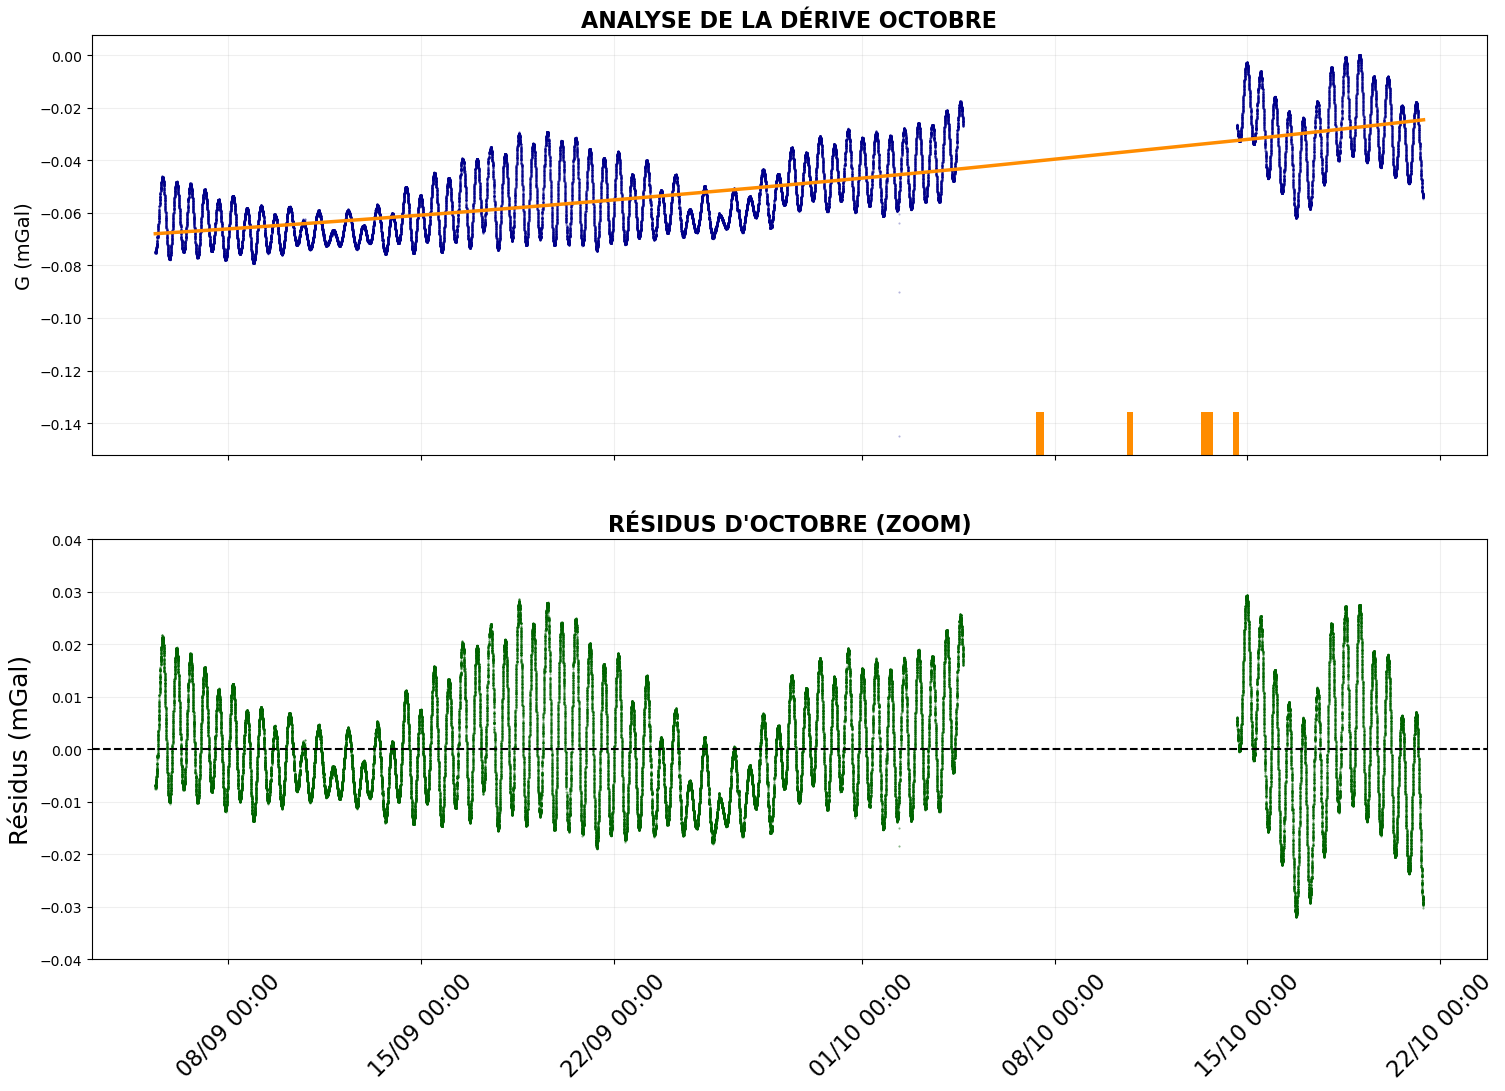

In [18]:
# ==========================================
# CELLULE 3 : FIT POLYNOMIAL (2nd DEGRÉ) - OCT
# ==========================================
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. CALCULS
df_fit_oct = df_oct_total.copy()
t_start = df_fit_oct['datetime'].min()
df_fit_oct['t_seconds'] = (df_fit_oct['datetime'] - t_start).dt.total_seconds()

X = df_fit_oct['t_seconds'].values
y = df_fit_oct['G_final_oct'].values

coeffs = np.polyfit(X, y, 2)
p = np.poly1d(coeffs)
y_trend = p(X)
df_fit_oct['Residus'] = y - y_trend

rmse_oct = np.sqrt(mean_squared_error(y, y_trend))
r2_oct = r2_score(y, y_trend)
pente_oct = (p(X[-1]) - p(X[0])) / ((X[-1] - X[0]) / 86400)

# 2. AFFICHAGE DES RÉSULTATS (Format complet)
print(f"--- RÉSULTATS OCTOBRE (18-21 SANS 17) ---")
print(f"Fichiers inclus : {df_fit_oct['file_index'].unique()}")
print(f"Précision (RMSE) : {rmse_oct:.6f} mGal")
print(f"Coefficient R² : {r2_oct:.6f}")
print(f"Formule de la dérive : G(t) = ({coeffs[0]:.6e})*t² + ({coeffs[1]:.6e})*t + {coeffs[2]:.6f}")
print(f"Dérive moyenne sur la période : {pente_oct:.5f} mGal/jour")

# Save stats
# Initialisation du dictionnaire si besoin
modeles_derive = {} if 'modeles_derive' not in locals() else modeles_derive
# Stockage avec TOUS les indicateurs pour le tableau récapitulatif
modeles_derive['oct'] = {
    'coeffs': coeffs,        # Le vecteur [a, b, c]
    't_start': t_start,      # La date de référence
    'rmse': rmse_oct,        # Ta variable de précision
    'r2': r2_oct,            # Ton coefficient R²
    'drift': pente_oct # Ta dérive en mGal/jour
}

# 3. VISUALISATION
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# Graph 1 : Trend + Timeline Survey
ax1.plot(df_fit_oct['datetime'], y, 'o', markersize=0.5, color='darkblue', alpha=0.3, label='Basement Data')
ax1.plot(df_fit_oct['datetime'], y_trend, color='darkorange', linewidth=2.5, label='Modèle Poly 2')

# Timeline Survey Orange
mask_s = (G_survey['datetime'] >= df_fit_oct['datetime'].min()) & \
         (G_survey['datetime'] <= df_fit_oct['datetime'].max())
survey_oct = G_survey.loc[mask_s]

if not survey_oct.empty:
    ax1.plot(survey_oct['datetime'], [y.min()] * len(survey_oct), '|', 
             markersize=35, mew=4, color='darkorange', label='Période Survey')

ax1.set_title("ANALYSE DE LA DÉRIVE OCTOBRE", fontsize=16, fontweight='bold')
ax1.set_ylabel("G (mGal)", fontsize=14)
ax1.grid(True, alpha=0.2)

# Graph 2 : Résidus
ax2.plot(df_fit_oct['datetime'], df_fit_oct['Residus'], 'o', markersize=0.5, color='darkgreen', alpha=0.5)
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title("RÉSIDUS D'OCTOBRE (ZOOM)", fontsize=16, fontweight='bold')
ax2.set_ylabel("Résidus (mGal)", fontsize=18)
ax2.set_ylim(-0.04, 0.04)
ax2.grid(True, alpha=0.2)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
plt.xticks(rotation=45, fontsize=16)
plt.show()

# CORRECTION

In [19]:
# =================================================================
# RÉCAPITULATIF FINAL : CALAGE SUR LES DATES DE SURVEY
# =================================================================

# --- ÉTAPE PRÉALABLE : On s'assure que 'period' existe ---
def get_period_key(dt):
    if dt.month == 4: return 'april'
    if dt.month == 5: return 'may'
    if dt.month == 6: return 'june'
    if dt.month == 7 and dt.day < 20: return 'july1'
    if (dt.month == 7 and dt.day >= 20) or dt.month == 8: return 'july2'
    if dt.month == 10: return 'oct'
    return None

# On recrée la colonne datetime et period au cas où
if 'datetime' not in G_survey.columns:
    G_survey['datetime'] = pd.to_datetime(df_survey['Date'] + ' ' + G_survey['Time'])

G_survey['period'] = G_survey['datetime'].apply(get_period_key)
# ---------------------------------------------------------

# 1. On crée le DataFrame à partir des modèles
df_recap = pd.DataFrame.from_dict(modeles_derive, orient='index')

# 2. On récupère les vraies dates de début depuis le fichier Survey
survey_starts = {}
for p in df_recap.index:
    mask = G_survey['period'] == p
    if mask.any():
        survey_starts[p] = G_survey.loc[mask, 'datetime'].min()

df_recap['Survey_Start'] = pd.Series(survey_starts)

# 3. Calcul de l'offset initial (la dérive cumulée au début du survey)
def calc_offset_start(row):
    if pd.isna(row['Survey_Start']): return np.nan
    t_ref = row['t_start']
    t0_survey = (row['Survey_Start'] - t_ref).total_seconds()
    a, b, c = row['coeffs']
    return a*(t0_survey**2) + b*t0_survey + c

df_recap['Drift_at_Start (mGal)'] = df_recap.apply(calc_offset_start, axis=1)

# 4. Nettoyage : Suppression de la ligne 'july' vide et conversion du R2
if 'july' in df_recap.index: 
    df_recap = df_recap.drop('july')

# Correction du bug d'affichage du R2 s'il existe
df_recap['r2'] = pd.to_numeric(df_recap['r2'], errors='coerce')

# 5. Renommage final
df_recap_final = df_recap.rename(columns={
    'rmse': 'RMSE (mGal)',
    'r2': 'R²',
    'drift': 'Drift Mean (mGal/j)',
    'Survey_Start': 'Survey Start Date'
})

# 6. Affichage
cols_to_show = [
    'Survey Start Date', 
    'Drift Mean (mGal/j)', 
    'RMSE (mGal)', 
    'R²', 
    'Drift_at_Start (mGal)'
]

print("📋 RÉCAPITULATIF CALIBRÉ SUR LES DATES DE TERRAIN")
display(df_recap_final[cols_to_show].sort_values('Survey Start Date'))

📋 RÉCAPITULATIF CALIBRÉ SUR LES DATES DE TERRAIN


,Survey Start Date,Drift Mean (mGal/j),RMSE (mGal),R²,Drift_at_Start (mGal)
april,2024-04-02 09:04:51,-0.006363,0.010225,0.934271,0.812397
may,2024-05-03 14:31:34,-0.005679,0.007928,0.969227,0.585894
june,2024-06-03 08:30:00,0.003913,0.009321,0.873537,0.113586
july1,2024-07-08 07:50:27,-0.000586,0.009667,0.210384,0.159969
july2,2024-07-31 08:12:28,0.004333,0.009704,0.877448,1.035648
oct,2024-10-07 10:02:07,0.000941,0.011378,0.553548,-0.040315


In [20]:
# =================================================================
# CELLULE FINALE : CORRECTION RELATIVE (START AT ZERO)
# =================================================================
import pandas as pd
import numpy as np

# 1. CHARGEMENT DU SURVEY
df_survey = pd.read_csv('Final_Precise_Raw_Gravity_Data.csv', sep=';', decimal=',')

# Conversion Date/Time
if 'datetime' not in df_survey.columns:
    df_survey['datetime'] = pd.to_datetime(df_survey['Date'] + ' ' + df_survey['Time'])

# 2. FONCTION DE MAPPING DES PÉRIODES
def get_period_key(dt):
    m, d = dt.month, dt.day
    if m == 4: return 'april'
    if m == 5: return 'may'
    if m == 6: return 'june'
    if m == 7 and d < 20: return 'july1'
    if (m == 7 and d >= 20) or m == 8: return 'july2'
    if m == 10: return 'oct'
    return None

df_survey['period'] = df_survey['datetime'].apply(get_period_key)

# 3. CALCUL DES OFFSETS DE DÉPART (Pour caler le premier point à 0)
offsets_initiaux = {}
print("--- CALCUL DES OFFSETS DE DÉPART (CALAGE À 0) ---")

for period in df_survey['period'].unique():
    if period and period in modeles_derive:
        # Trouver la date de la première mesure du survey pour ce mois
        first_date = df_survey[df_survey['period'] == period]['datetime'].min()
        
        # Récupérer le modèle correspondant
        m = modeles_derive[period]
        t_ref = m['t_start']
        a, b, c = m['coeffs']
        
        # Calcul de la valeur de la dérive au moment exact du début du survey
        t0_seconds = (first_date - t_ref).total_seconds()
        val_zero = a*(t0_seconds**2) + b*t0_seconds + c
        
        offsets_initiaux[period] = val_zero
        print(f"📍 {period.upper().ljust(6)} : Premier point le {first_date} -> Offset soustrait : {val_zero:.6f} mGal")

# 4. APPLICATION DE LA CORRECTION RELATIVE
def appliquer_correction_relative(row):
    period = row['period']
    dt = row['datetime']
    
    if period and period in modeles_derive:
        m = modeles_derive[period]
        a, b, c = m['coeffs']
        t_ref = m['t_start']
        
        # Temps écoulé depuis le début du modèle continuous
        t = (dt - t_ref).total_seconds()
        
        # Dérive absolue selon le modèle
        drift_absolue = a*(t**2) + b*t + c
        
        # Dérive relative (on soustrait l'offset du premier point du mois)
        return drift_absolue - offsets_initiaux[period]
    return np.nan

# Application du calcul
df_survey['Drift_Estimated'] = df_survey.apply(appliquer_correction_relative, axis=1)

# Calcul du G final corrigé
# Note : ObsG doit être ta colonne de gravité brute
df_survey['G_final_corrected'] = df_survey['ObsG'] - df_survey['Drift_Estimated']

# 5. VÉRIFICATION ET AFFICHAGE
print("\n--- VÉRIFICATION DU DÉPART À ZÉRO ---")
check = df_survey.dropna(subset=['Drift_Estimated']).groupby('period')['Drift_Estimated'].first()
for p, val in check.items():
    print(f"✅ {p.ljust(6)} : Drift initial = {val:.6f} mGal")

# Affichage d'un échantillon
display(df_survey[['datetime', 'period', 'ObsG', 'Drift_Estimated', 'G_final_corrected']].dropna().head(10))

# 6. SAUVEGARDE FINALE
df_survey.to_csv('Survey_details_Data_drift_corrected.csv', index=False, sep=';', decimal=',')
print("\n🚀 Traitement terminé ! Fichier prêt.")

--- CALCUL DES OFFSETS DE DÉPART (CALAGE À 0) ---
📍 APRIL  : Premier point le 2024-04-02 09:04:51 -> Offset soustrait : 0.812397 mGal
📍 MAY    : Premier point le 2024-05-03 14:31:34 -> Offset soustrait : 0.585894 mGal
📍 JUNE   : Premier point le 2024-06-03 08:30:00 -> Offset soustrait : 0.113586 mGal
📍 JULY1  : Premier point le 2024-07-08 07:50:27 -> Offset soustrait : 0.159969 mGal
📍 JULY2  : Premier point le 2024-07-31 08:12:28 -> Offset soustrait : 1.035648 mGal
📍 OCT    : Premier point le 2024-10-07 10:02:07 -> Offset soustrait : -0.040315 mGal

--- VÉRIFICATION DU DÉPART À ZÉRO ---
✅ april  : Drift initial = 0.000000 mGal
✅ july1  : Drift initial = 0.000000 mGal
✅ july2  : Drift initial = 0.000000 mGal
✅ june   : Drift initial = 0.000000 mGal
✅ may    : Drift initial = 0.000000 mGal
✅ oct    : Drift initial = 0.000000 mGal


,datetime,period,ObsG,Drift_Estimated,G_final_corrected
0,2024-04-02 09:04:51,april,-0.008,0.000000,-0.008000
1,2024-04-02 09:05:08,april,-0.015,-0.000002,-0.014998
2,2024-04-02 09:06:31,april,-0.014,-0.000012,-0.013988
3,2024-04-02 09:07:11,april,-0.013,-0.000016,-0.012984
4,2024-04-02 09:07:30,april,-0.015,-0.000019,-0.014981
5,2024-04-02 09:07:47,april,-0.014,-0.000021,-0.013979
6,2024-04-02 09:08:15,april,-0.014,-0.000024,-0.013976
7,2024-04-02 09:08:38,april,-0.016,-0.000027,-0.015973
8,2024-04-02 09:09:13,april,-0.015,-0.000031,-0.014969
9,2024-04-02 11:54:05,april,-0.030,-0.001194,-0.028806



🚀 Traitement terminé ! Fichier prêt.


In [21]:
# =================================================================
# CELLULE FINALE : REMPLACEMENT, ARRONDI ET NETTOYAGE
# =================================================================
import pandas as pd

# 1. ON OUVRE LE FICHIER CALCULÉ
df = pd.read_csv('Survey_details_Data_drift_corrected.csv', sep=';', decimal=',')

# 2. ON ÉCRASE ObsG AVEC LA VALEUR CORRIGÉE ET ARRONDIE
# .round(3) permet de garder exactement 3 chiffres après la virgule
df['ObsG'] = df['G_final_corrected'].round(6)

# 3. ON SUPPRIME LES COLONNES DE CALCUL
colonnes_a_supprimer = ['datetime', 'period', 'Drift_Estimated', 'G_final_corrected']
df.drop(columns=colonnes_a_supprimer, inplace=True, errors='ignore')

# 4. SAUVEGARDE DU FICHIER FINAL
df.to_csv('Final_Data_Drift_corrected.csv', index=False, sep=',', decimal='.')

# Aperçu pour vérifier l'arrondi
display(df.head(5))

,Station ID,Observer ID,Serial Number,Date,Time,ObsG,Dial,Feedback Correction,Earthtide Correction,Level Correction,...,Beam Error,Height,Elevation,Latitude,Longitude,Elapsed Time,Standard Deviation,Temperature Frequency,Note,Gradient
0,3RDB,pablo,B-28,2024/04/02,09:04:51,-0.008000,2495,-0.017,-0.029,0,...,0.0010,25.2,2224.2171,28.234672,-16.629831,67,0.0057,0,No notes.,3.086
1,3RDB,pablo,B-28,2024/04/02,09:05:08,-0.014998,2495,-0.024,-0.029,0,...,-0.0012,25.2,2224.2171,28.234672,-16.629831,84,0.0079,0,No notes.,3.086
2,3RDB,pablo,B-28,2024/04/02,09:06:31,-0.013988,2495,-0.024,-0.029,0,...,0.0001,25.2,2224.2171,28.234672,-16.629831,167,0.0077,0,No notes.,3.086
3,3RDB,pablo,B-28,2024/04/02,09:07:11,-0.012984,2495,-0.022,-0.029,0,...,0.0007,25.2,2224.2171,28.234672,-16.629831,207,0.0044,0,No notes.,3.086
4,3RDB,pablo,B-28,2024/04/02,09:07:30,-0.014981,2495,-0.024,-0.029,0,...,-0.0002,25.2,2224.2171,28.234672,-16.629831,226,0.0052,0,No notes.,3.086


In [22]:
df = pd.read_csv('Final_Precise_Raw_Gravity_Data.csv', sep=';', decimal=',')
df.to_csv('Final_Precise_Raw_Gravity_Data2.csv', index=False, sep=',', decimal='.')

# Convert ObsG en corrected for height instrument 

In [23]:
import pandas as pd

# 1. Configuration des fichiers
input_file = 'Final_Data_Drift_corrected.csv'
output_file = 'FINAL_Data_Drift_corrected_Ground_Level.csv'

try:
    # Lecture du fichier
    # Note : Si votre CSV utilise des points-virgules, ajoutez sep=';'
    df = pd.read_csv(input_file)
    
    # Vérification de la présence des colonnes
    if 'ObsG' in df.columns and 'Height' in df.columns:
        
        # 2. Calcul de la correction de l'air libre
        # Gradient théorique : 0.3086 mGal/m = 0.003086 mGal/cm
        gradient_cm = 0.3086 / 100
        
        # Application de la correction et ARRONDI à 3 décimales
        df['ObsG'] = (df['ObsG'] + (df['Height'] * gradient_cm)).round(6)
        
        # 3. Mise à zéro de la colonne Height
        df['Height'] = 0

        # Supprime la colonne 'Gradient' 
        df = df.drop(columns=['Gradient'], errors='ignore')
        
        # 4. Sauvegarde avec formatage à 3 décimales pour ObsG
        df.to_csv(output_file, index=False)
        
    else:
        print("Erreur : Les colonnes 'ObsG' ou 'Height' sont introuvables.")

except FileNotFoundError:
    print(f"Erreur : Le fichier '{input_file}' est introuvable.")

# Combine Dial and ObsG + expot en BURRIS AND CSV

In [24]:
import pandas as pd

# =================================================================
# PRÉPARATION DES DONNÉES POUR GSADJUST (MODE TOTAL GRAVITY)
# =================================================================

# 1. Chargement des données
# On charge le fichier où tu as déjà corrigé le drift sur la partie fractionnaire
input_file = 'FINAL_Data_Drift_corrected_Ground_Level.csv'
df = pd.read_csv(input_file)

# Nettoyage des noms de colonnes (au cas où il y aurait des espaces cachés)
df.columns = df.columns.str.strip()

# 2. Création de la Pesanteur Totale (Somme du Dial et de l'ObsG)
# Rappel : Dial = partie entière (~2400), ObsG = partie décimale corrigée (~0.123)
# On utilise une variable intermédiaire pour ne pas s'emmêler les pinceaux
scale_factor = 1.0  # Valeur par défaut pour un Burris

df['Gravity_Total'] = (df['Dial'] * scale_factor) + df['ObsG']

# 3. Préparation du format pour GSadjust
# On crée un nouveau DataFrame avec seulement ce dont GSadjust a besoin
# On renomme 'Gravity_Total' en 'ObsG' car c'est le nom de colonne que GSadjust cherche par défaut
df_final = df.copy()
df_final['ObsG'] = df['Gravity_Total']

# 4. MISE À ZÉRO DU DIAL
# On garde la colonne pour que le "Header" Burris soit respecté, 
# mais on met tout à 0 pour éviter la double addition.
df_final['Dial'] = 0

# Supprime la colonne 'Gradient' 
df = df.drop(columns=['Gravity_Total'], errors='ignore')

# 5. Exportation
output_file = 'FINAL_Data_for_GSadjust_BURRIS.csv'
df_final.to_csv(output_file, index=False)

# =================================================================
# VÉRIFICATION DE COHÉRENCE
# =================================================================
print(f"✅ Fichier prêt : {output_file}")
print("-" * 50)
print("Vérification des valeurs (moyennes par station) :")

# On affiche les premières lignes pour vérifier que ObsG est bien autour de 2400-2500
check = df_final.groupby('Station ID')['ObsG'].mean().sort_values(ascending=False)
print(check.head(10))

# Petit test sur tes stations GUI si elles sont présentes
if 'GUI20' in check.index and 'GUI30' in check.index:
    diff = check['GUI20'] - check['GUI30']
    print(f"\n📢 Écart GUI20 - GUI30 : {diff:.3f} mGal")
    print("(Si cet écart est proche de 40-70 mGal, c'est que le calcul est enfin juste !)")

# Vérification visuelle
print("\nTop 5 des lignes fusionnées :")
print(df_final[['Station ID', 'Dial', 'ObsG']].head())

✅ Fichier prêt : FINAL_Data_for_GSadjust_BURRIS.csv
--------------------------------------------------
Vérification des valeurs (moyennes par station) :
Station ID
ORO08       2943.030756
ORO00       2940.998402
ORO01       2935.242519
ORO07       2925.061287
ORO02       2909.200890
ORO06       2899.080291
ORO05       2873.134046
GUI12       2862.890986
IPNA_out    2835.132906
GUI10       2834.893021
Name: ObsG, dtype: float64

📢 Écart GUI20 - GUI30 : -39.803 mGal
(Si cet écart est proche de 40-70 mGal, c'est que le calcul est enfin juste !)

Top 5 des lignes fusionnées :
  Station ID  Dial         ObsG
0       3RDB     0  2495.069767
1       3RDB     0  2495.062769
2       3RDB     0  2495.063779
3       3RDB     0  2495.064783
4       3RDB     0  2495.062786
